# 🌊 Bangalore Lakes Water Quality — Complete ML Pipeline (Updated)

**Dataset:** Master dataset of Bangalore lake water quality monitoring (Jul 2023 – Nov 2025)  
**File:** `master_dataset.csv` (located in the same `Analysis/` folder)

## Pipeline Overview
| Stage | Description |
|-------|-------------|
| 1 | Data Loading & EDA |
| 2 | Cleaning, Preprocessing & Outlier Detection (IQR capping) |
| 3 | Feature Engineering (temporal features only — numerical) |
| 4 | **80-20 Train/Test Split** |
| 5 | **12 Classical ML Models** for 9 targets |
| 6 | **GridSearchCV** Hyperparameter Tuning |
| 7 | **Deep Learning**: FNN, 1D-CNN, LSTM |
| 8 | Comparison Tables & Visualisations (all saved to `images/`) |
| 9 | **Future Forecasting**: Months 4–8, 2026 |
| 10 | Export Predictions |

**Target Factors (numerical only):**  
`DO`, `BOD`, `CARBONATE`, `BICARBONATE`, `TOTALALKALINITY` *(best alkalinity factor)*,  
`TOTALHARDNESS`, `TOTALDISSOLVEDSOLIDS`, `TOTALSUSPENDEDSOLIDS`

> **Note:** `STN_CODE`, `MONTH_YEAR`, `NAMEOFMONITORINGLOCATION`, `USEBASEDCLASS` are excluded as prediction targets (non-numerical / categorical identifiers).

---
## 0. Install & Import Dependencies

In [1]:
# Uncomment to install missing packages
# !pip install scikit-learn xgboost lightgbm tensorflow pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Create images/ directory for all plots ────────────────────────────────────
IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f'📁 images/ directory ready: {IMAGES_DIR.resolve()}')

def savefig(name):
    """Save figure to images/ folder."""
    path = IMAGES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  💾 Saved → {path}')

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ── Optional boosting libs ────────────────────────────────────────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False; print('xgboost not found')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False; print('lightgbm not found')

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    HAS_TF = True
    print(f'TensorFlow {tf.__version__}')
except ImportError:
    HAS_TF = False; print('TensorFlow not found — neural net section skipped')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Imports complete')

📁 images/ directory ready: /Users/knight_striker/Desktop/Correlation-Expression-Prediction/Analysis/images
TensorFlow 2.21.0
✅ Imports complete


---
## 1. Data Loading & Exploratory Data Analysis

In [2]:
DATA_PATH = Path('master_dataset.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (2924, 34)


,MONTH_YEAR,STN_CODE,NAMEOFMONITORINGLOCATION,USEBASEDCLASS,DO,PH,CONDUCTIVITY,BOD,NITRATE_N,FECAL_COLI,...,TOTALDISSOLVEDSOLIDS,TOTALSUSPENDEDSOLIDS,PHOSPHATE,BORON,POTASSIUM,FLUORIDE,SODIUMPERCENTAGE,SAR,ORTHOPHOSPHATE,YEAR
0,07/23,5574.0,DEVASANDRA LAKE,"D (Propagation of wild life,fisheries)",4.4,8.2,392.0,7.0,1.0,6300.0,...,268.0,12.175824,0.56,0.5,13.0,0.23,43.956044,1.794505,0.297253,2023.0
1,07/23,5574.0,HEBBAL LAKE,"D (Propagation of wild life,fisheries)",4.7,7.2,550.0,8.0,2.0,2300.0,...,376.0,12.351648,0.98,0.5,27.0,0.28,43.912088,1.789011,0.294505,2023.0
2,07/23,5574.0,JAKKUR LAKE,"E (Irrigation, industrial cooling and controll...",2.6,7.0,908.0,12.0,4.1,4000.0,...,620.0,12.527473,2.40,0.5,32.0,0.45,43.868132,1.783516,0.291758,2023.0


In [3]:
# Null counts & dtypes
info = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'nulls':    df_raw.isnull().sum(),
    'null_pct': (df_raw.isnull().mean()*100).round(2)
})
print(info.to_string())

                             dtype  nulls  null_pct
MONTH_YEAR                     str      0       0.0
STN_CODE                   float64      0       0.0
NAMEOFMONITORINGLOCATION       str      0       0.0
USEBASEDCLASS                  str      0       0.0
DO                         float64      0       0.0
PH                         float64      0       0.0
CONDUCTIVITY               float64      0       0.0
BOD                        float64      0       0.0
NITRATE_N                  float64      0       0.0
FECAL_COLI                 float64      0       0.0
TOTAL_COLI                 float64      0       0.0
CARBONATE                  float64      0       0.0
BICARBONATE                float64      0       0.0
PHENOLPHTHALEINALKALINITY  float64      0       0.0
TOTALALKALINITY            float64      0       0.0
CHLORIDES                  float64      0       0.0
COD                        float64      0       0.0
TOTALKJELDAHLNITROGEN      float64      0       0.0
AMMONICALN  

In [4]:
# Numerical summary
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
STN_CODE,2924.0,4.176440e+03,1.165237e+03,6.30,3615.000000,4506.000000,4540.000000,5.844000e+03
DO,2924.0,4.089538e+00,1.956669e+00,0.02,2.800000,4.600000,5.700000,8.000000e+00
PH,2924.0,8.162867e+02,2.654938e+04,1.90,7.000000,7.400000,7.900000,1.100000e+06
CONDUCTIVITY,2924.0,4.817319e+03,1.245847e+05,63.00,512.000000,740.000000,1140.000000,4.900000e+06
BOD,2924.0,1.481648e+01,2.021884e+01,3.20,5.000000,8.000000,17.000000,4.500000e+02
NITRATE_N,2924.0,3.379207e+00,2.900932e+00,0.30,1.870000,2.800000,4.000000,4.900000e+01
FECAL_COLI,2924.0,4.455898e+05,2.038215e+07,2.00,230.000000,630.000000,2600.000000,1.100000e+09
TOTAL_COLI,2924.0,1.579365e+06,6.171097e+07,1.50,2400.000000,5400.000000,16000.000000,3.300000e+09
CARBONATE,2924.0,1.899248e+01,4.262540e+01,3.00,3.000000,3.000000,18.862857,4.360000e+02
BICARBONATE,2924.0,1.940414e+02,1.407183e+02,8.00,112.000000,156.000000,240.000000,2.590000e+03


✅ All 8 target columns found: ['DO', 'BOD', 'CARBONATE', 'BICARBONATE', 'TOTALALKALINITY', 'TOTALHARDNESS', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS']
  💾 Saved → images/01_target_distributions_raw.png


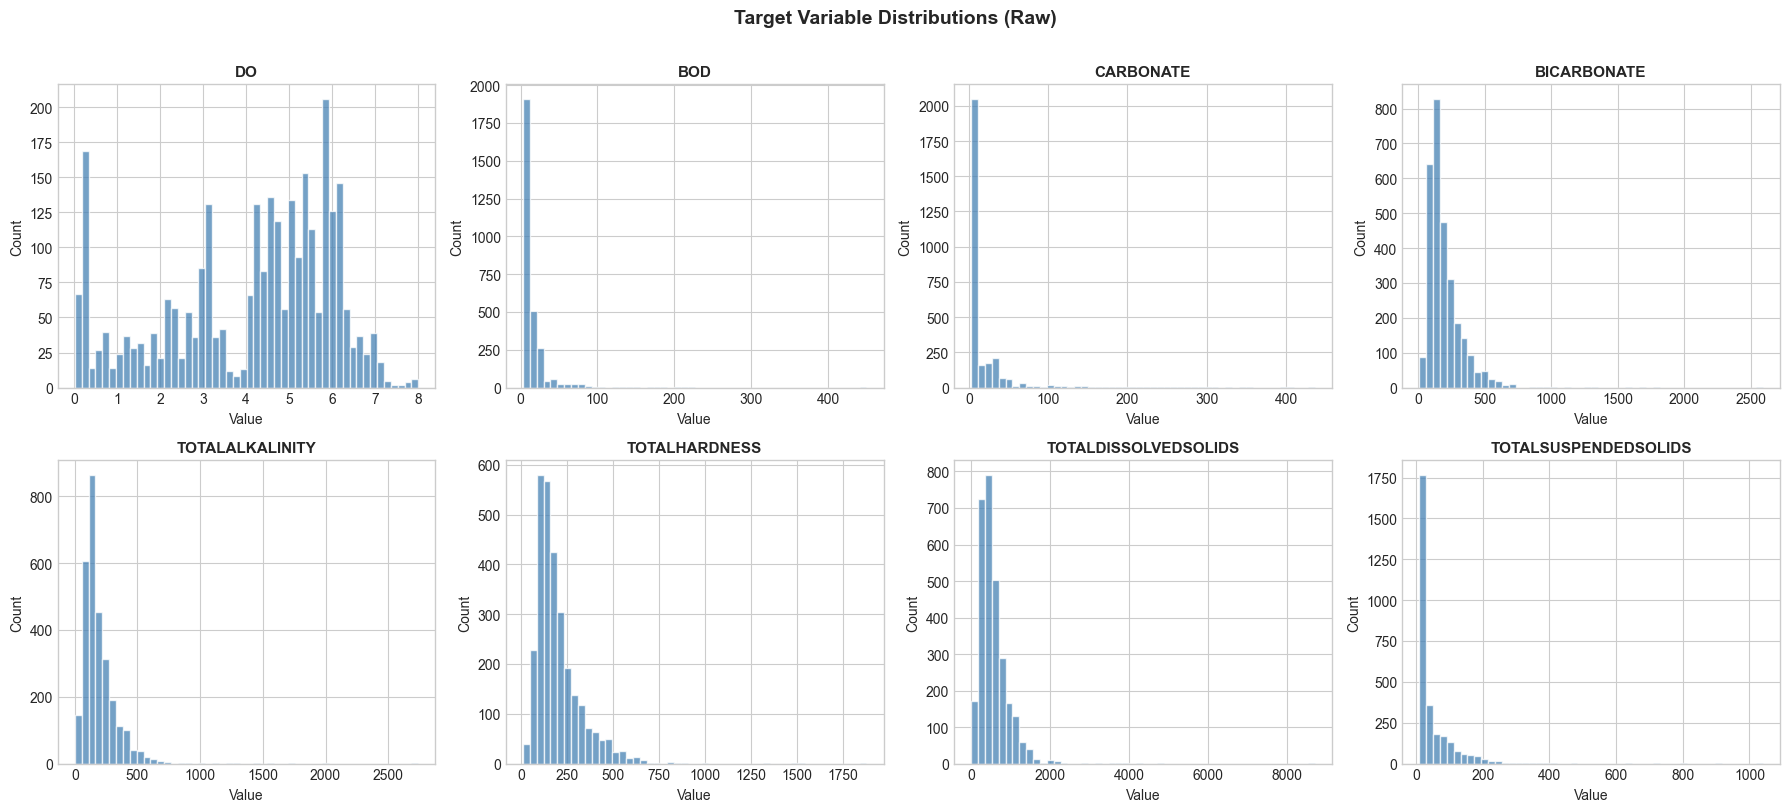

In [5]:
# ── EDA: Target distributions ─────────────────────────────────────────────────
# Updated TARGETS — 9 numerical targets as requested
TARGETS = [
    'DO', 'BOD', 'CARBONATE', 'BICARBONATE',
    'TOTALALKALINITY',       # Best alkalinity factor (comprehensive measure)
    'TOTALHARDNESS', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS'
]

# Verify all targets exist
missing_targets = [t for t in TARGETS if t not in df_raw.columns]
if missing_targets:
    print(f'⚠️  Missing columns: {missing_targets}')
else:
    print(f'✅ All {len(TARGETS)} target columns found: {TARGETS}')

# Plot distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(TARGETS):
    if col in df_raw.columns:
        axes[i].hist(df_raw[col].dropna(), bins=50, color='steelblue', alpha=0.75, edgecolor='white')
        axes[i].set_title(col, fontweight='bold', fontsize=11)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
plt.suptitle('Target Variable Distributions (Raw)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('01_target_distributions_raw.png')
plt.show()

  💾 Saved → images/02_correlation_heatmap.png


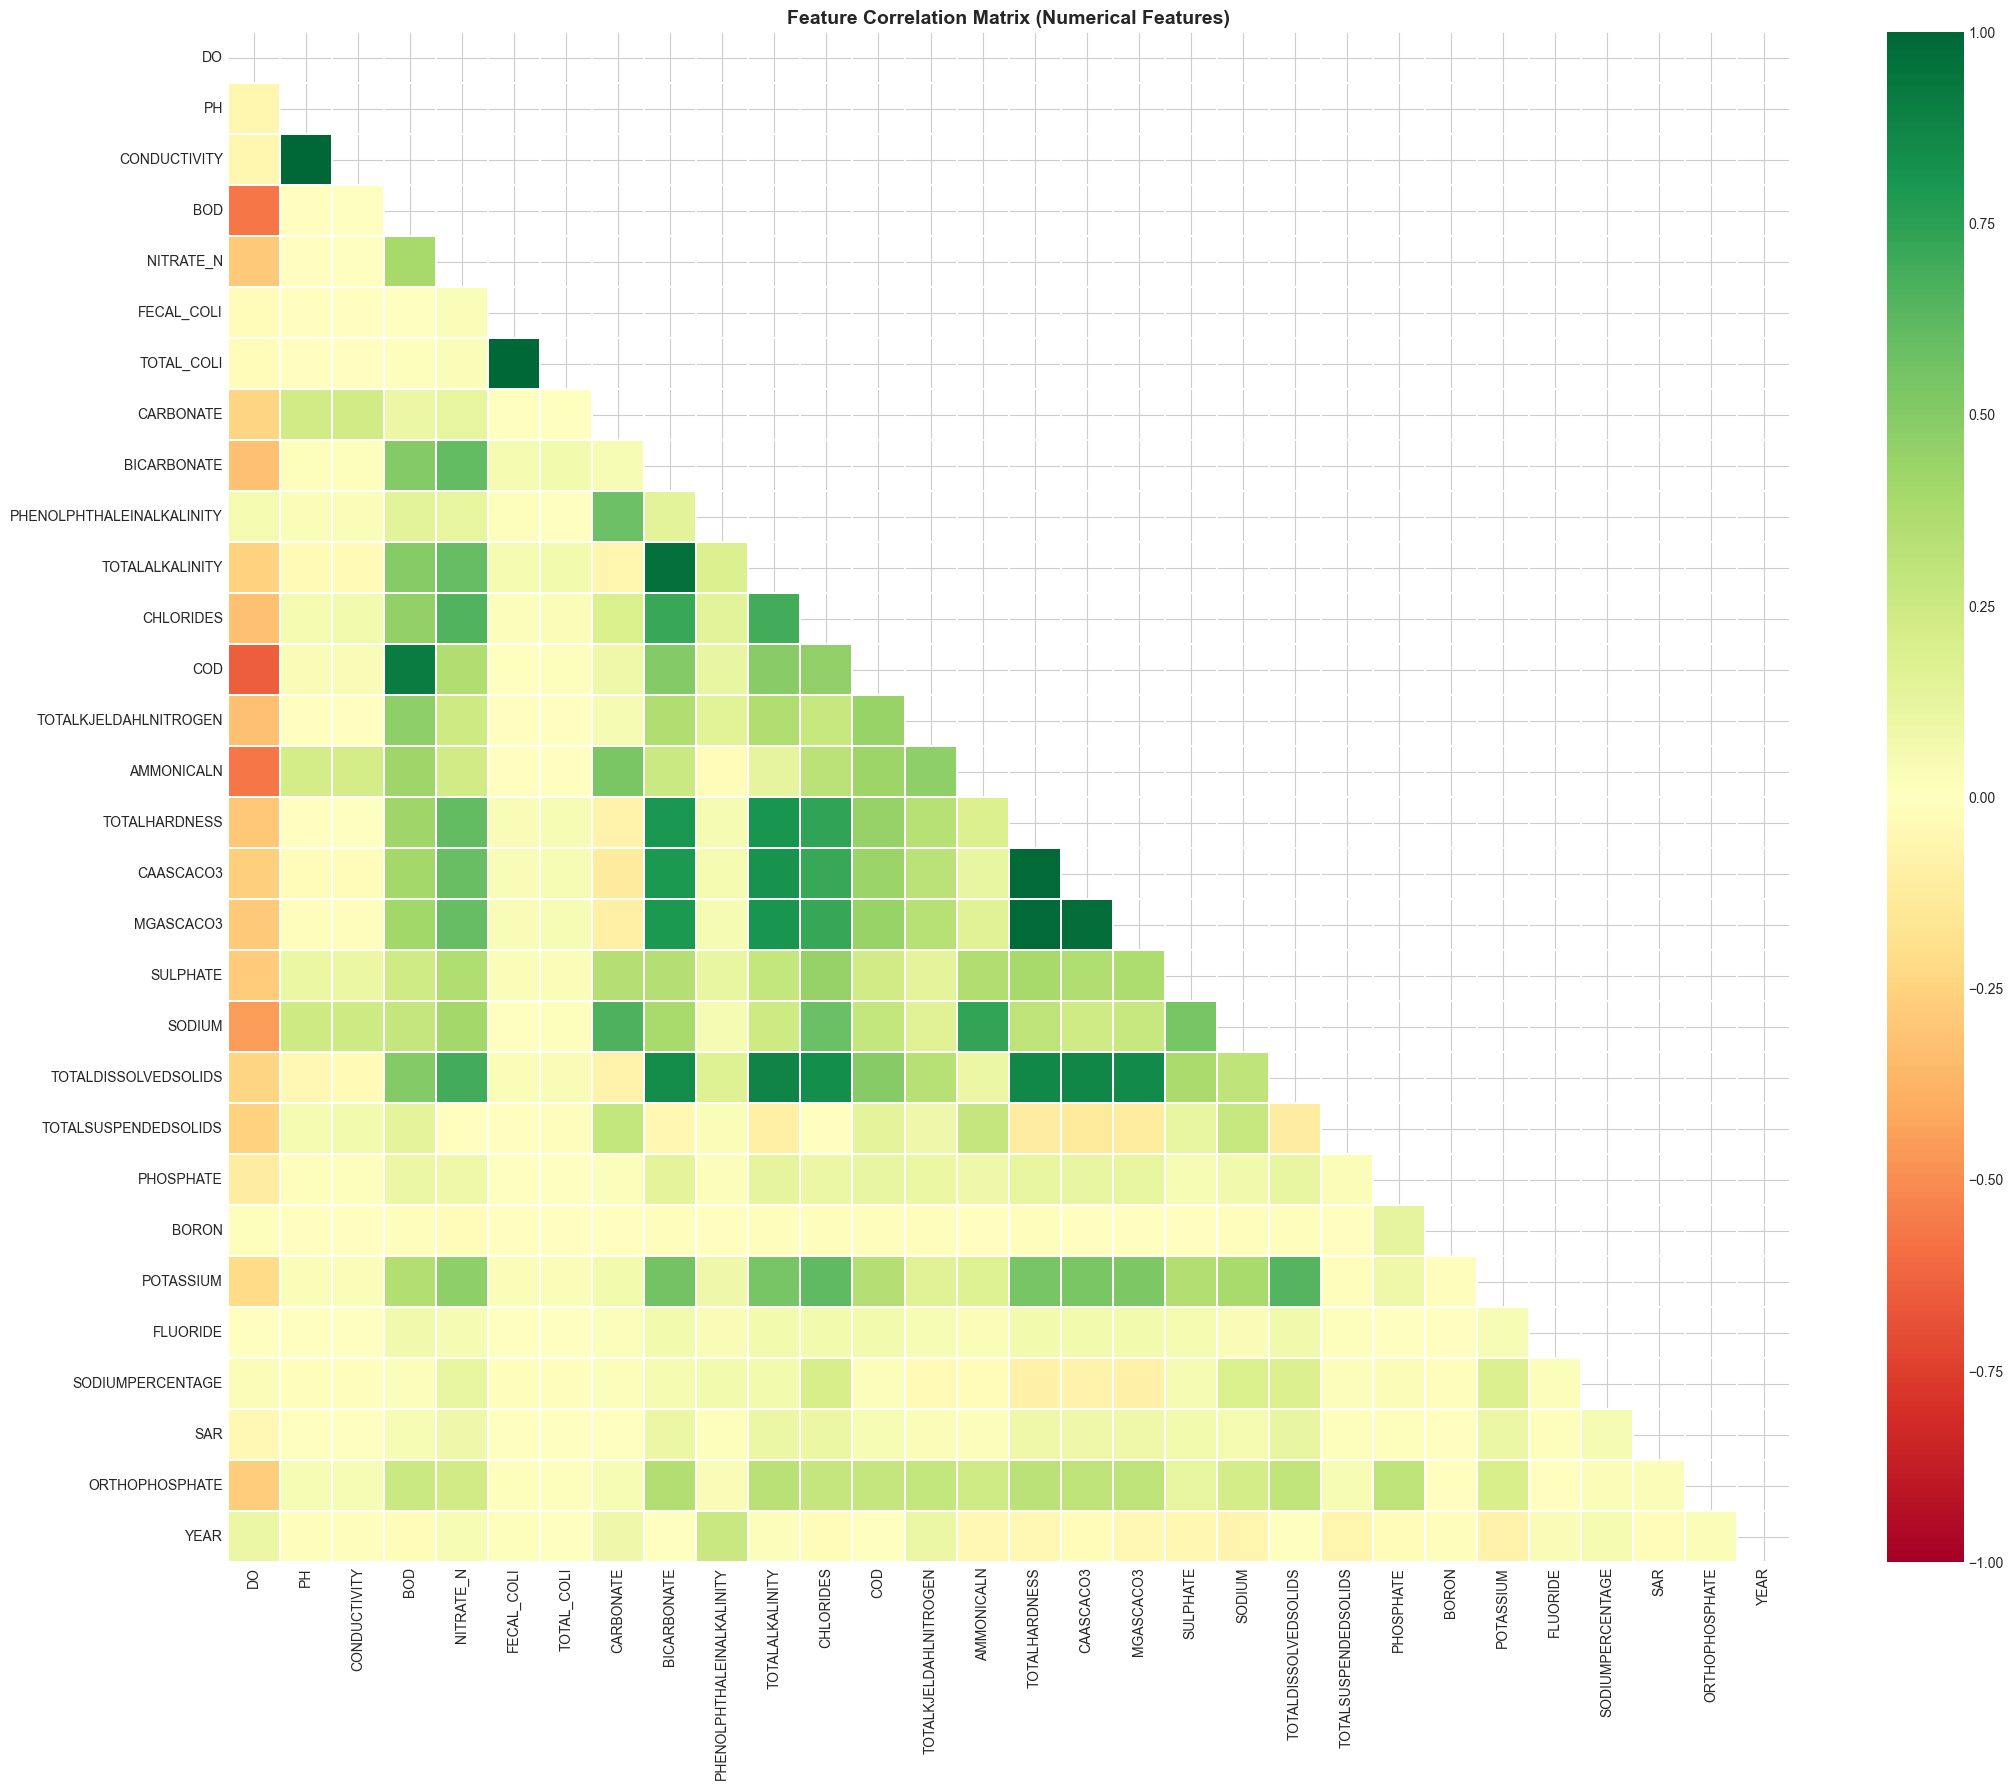

In [6]:
# ── EDA: Correlation heatmap (numerical columns only) ────────────────────────
# Exclude non-numerical identifier columns
EXCLUDE_COLS = ['MONTH_YEAR', 'STN_CODE', 'NAMEOFMONITORINGLOCATION', 'USEBASEDCLASS']
num_cols = [c for c in df_raw.columns if c not in EXCLUDE_COLS and df_raw[c].dtype in ['float64','int64']]

corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('02_correlation_heatmap.png')
plt.show()

  💾 Saved → images/03_monthly_trends.png


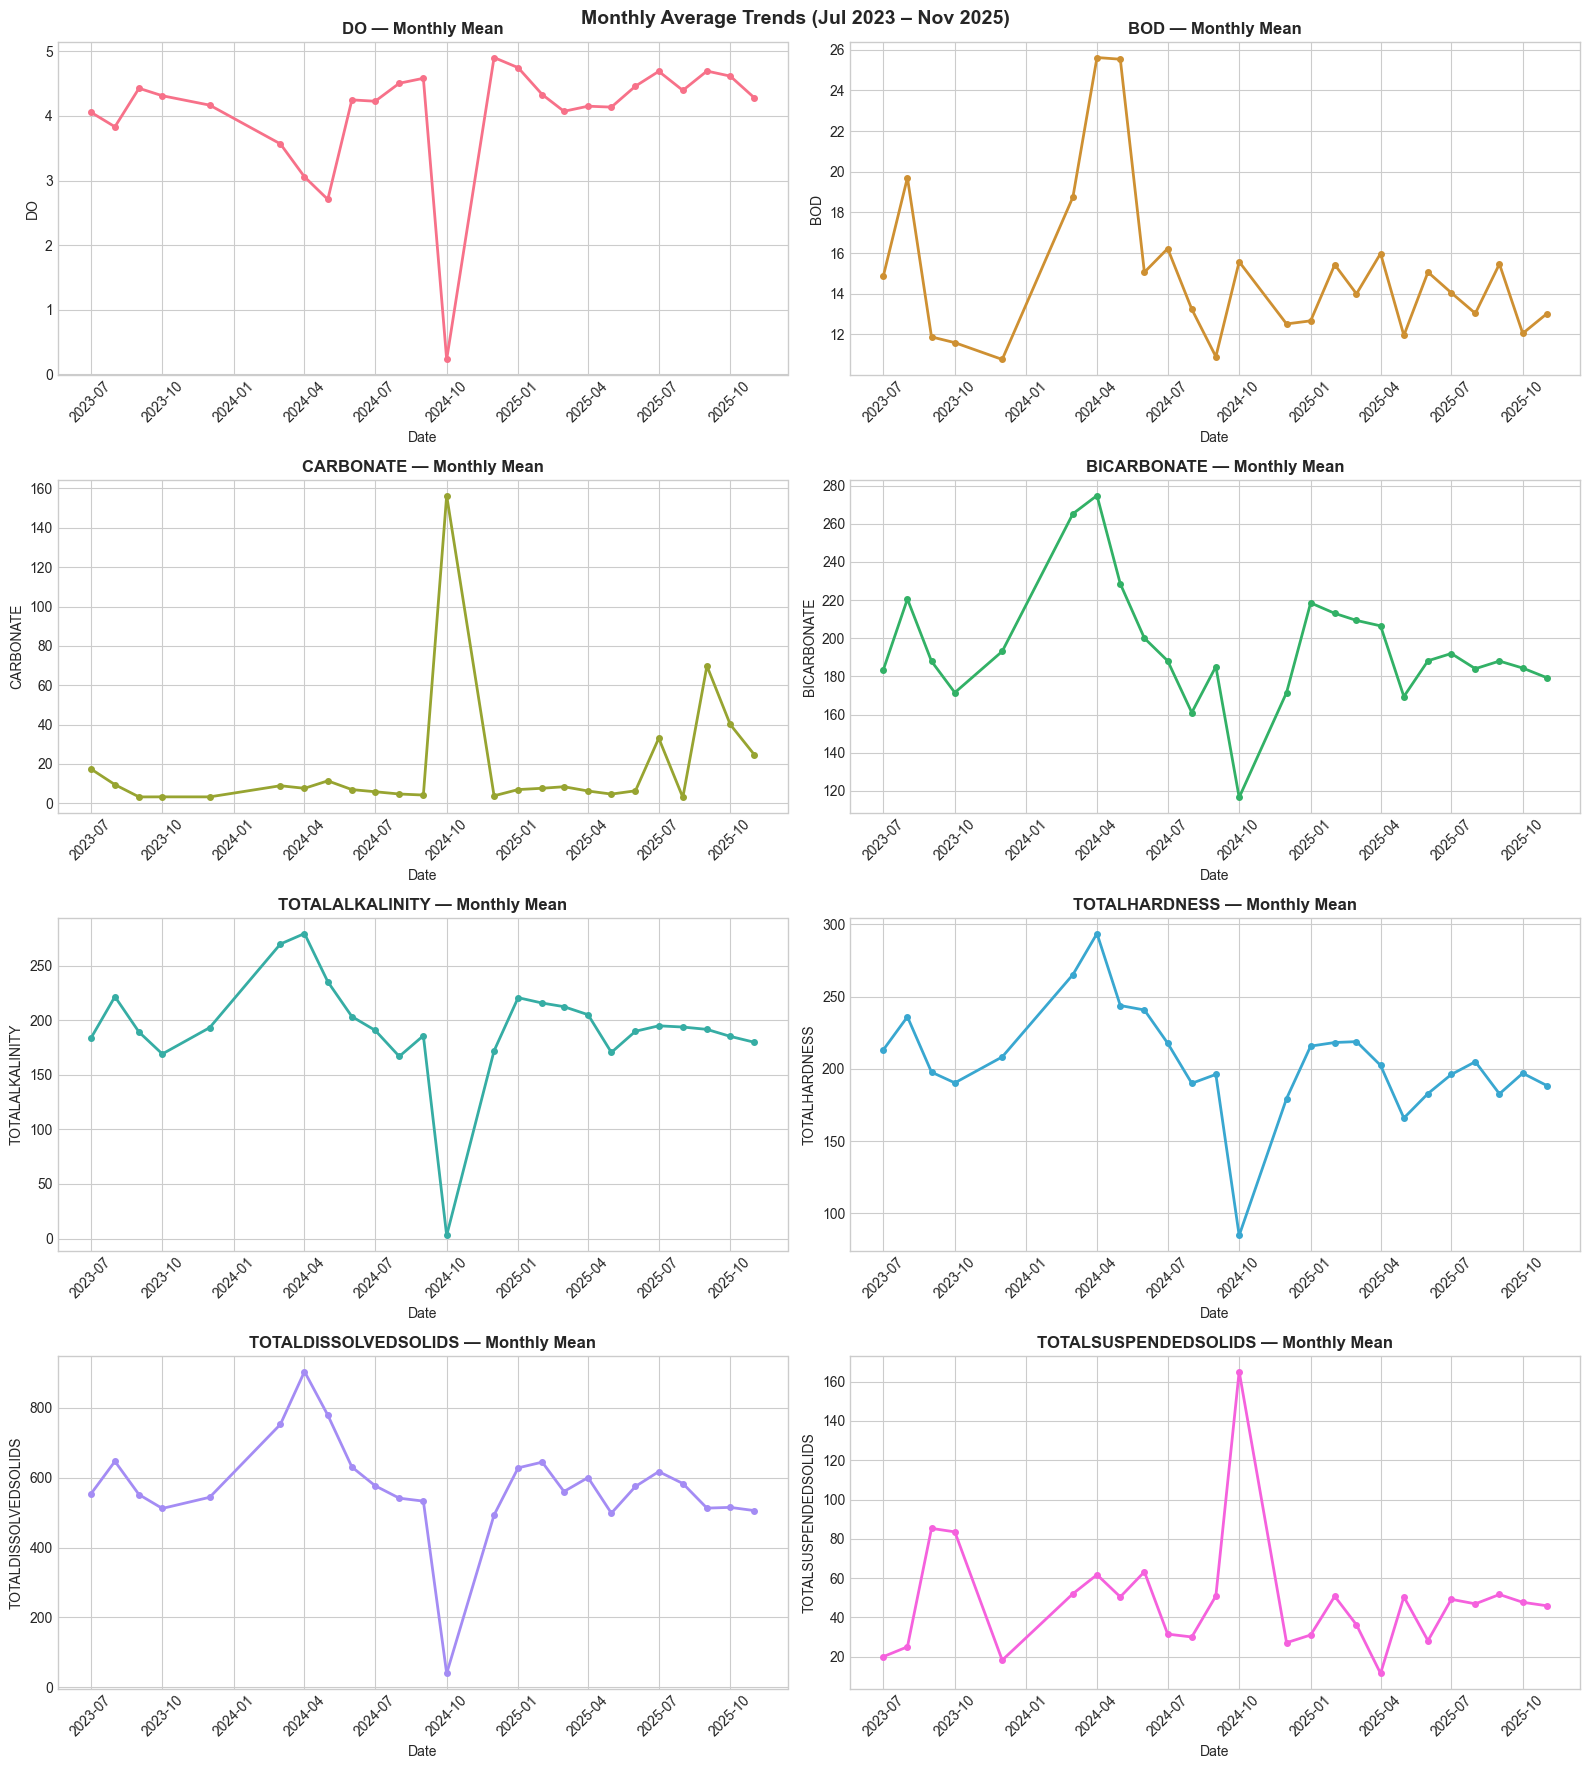

In [7]:
# ── EDA: Time-series trend of targets ────────────────────────────────────────
df_ts = df_raw.copy()
df_ts['DATE'] = pd.to_datetime(df_ts['MONTH_YEAR'], format='%m/%y', errors='coerce')
df_ts = df_ts.dropna(subset=['DATE'])
monthly_mean = df_ts.groupby('DATE')[TARGETS].mean()

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()
for i, col in enumerate(TARGETS):
    if col in monthly_mean.columns:
        axes[i].plot(monthly_mean.index, monthly_mean[col], marker='o', linewidth=2,
                     markersize=4, color=sns.color_palette('husl', 8)[i])
        axes[i].set_title(f'{col} — Monthly Mean', fontweight='bold')
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Monthly Average Trends (Jul 2023 – Nov 2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('03_monthly_trends.png')
plt.show()

---
## 2. Cleaning, Preprocessing & Outlier Detection

In [8]:
df = df_raw.copy()

# ── Keep only numerical feature columns + MONTH_YEAR for temporal engineering
# Exclude non-numerical identifier/categorical columns from FEATURES
CATEGORICAL_COLS = ['STN_CODE', 'NAMEOFMONITORINGLOCATION', 'USEBASEDCLASS']

# ── Parse date for temporal features ─────────────────────────────────────────
df['DATE'] = pd.to_datetime(df['MONTH_YEAR'], format='%m/%y', errors='coerce')
df['MONTH']        = df['DATE'].dt.month
df['YEAR_NUM']     = df['DATE'].dt.year
df['MONTH_SIN']    = np.sin(2 * np.pi * df['MONTH'] / 12)
df['MONTH_COS']    = np.cos(2 * np.pi * df['MONTH'] / 12)
df['TIME_INDEX']   = (df['YEAR_NUM'] - 2023) * 12 + df['MONTH']  # monotonic time index

print('✅ Temporal features added: MONTH, YEAR_NUM, MONTH_SIN, MONTH_COS, TIME_INDEX')

# ── Drop original date/categorical columns — only numerical remain as features
df = df.drop(columns=['MONTH_YEAR', 'DATE'] + CATEGORICAL_COLS, errors='ignore')

# ── Impute remaining NaNs (median) ───────────────────────────────────────────
num_feature_cols = [c for c in df.columns if df[c].dtype in ['float64','int64']]
imputer = SimpleImputer(strategy='median')
df[num_feature_cols] = imputer.fit_transform(df[num_feature_cols])
print(f'✅ Imputed {len(num_feature_cols)} numerical columns — nulls remaining: {df.isnull().sum().sum()}')

✅ Temporal features added: MONTH, YEAR_NUM, MONTH_SIN, MONTH_COS, TIME_INDEX
✅ Imputed 32 numerical columns — nulls remaining: 0


✅ IQR capping applied. Shape after cleaning: (2924, 35)
  💾 Saved → images/04_target_distributions_cleaned.png


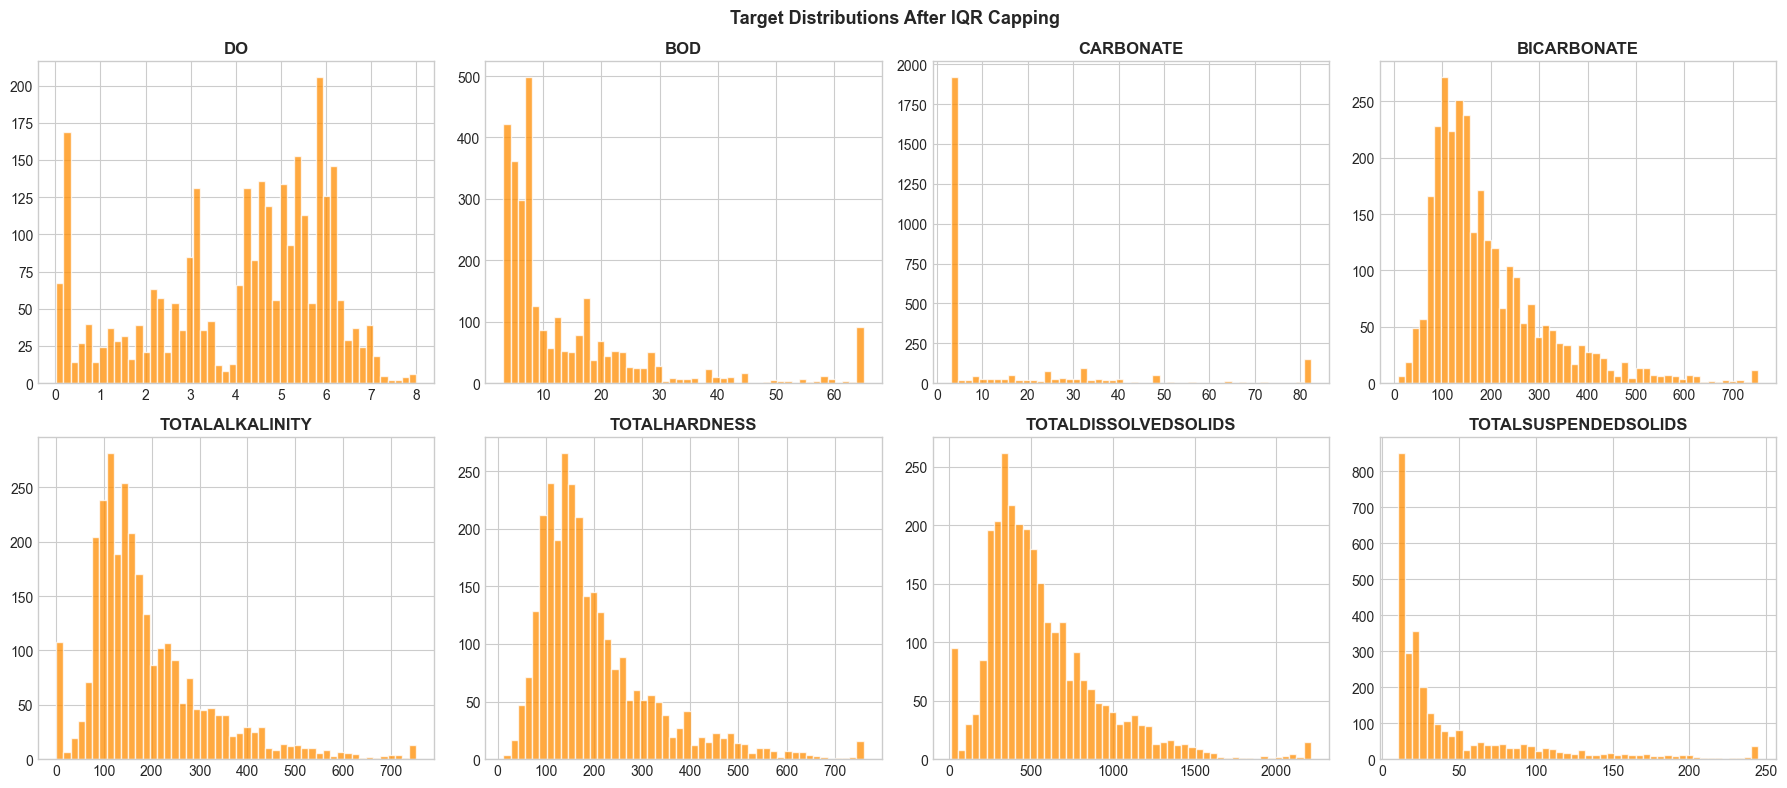

In [9]:
# ── Outlier Capping (IQR method) ─────────────────────────────────────────────
def cap_iqr(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(q1 - factor * iqr, q3 + factor * iqr)

cap_cols = [c for c in df.columns if c not in TARGETS + ['MONTH','YEAR_NUM','MONTH_SIN','MONTH_COS','TIME_INDEX']]
for col in cap_cols:
    if df[col].dtype in ['float64','int64']:
        df[col] = cap_iqr(df[col])

# Also cap targets (lighter factor for targets)
for col in TARGETS:
    if col in df.columns:
        df[col] = cap_iqr(df[col], factor=4.0)

print(f'✅ IQR capping applied. Shape after cleaning: {df.shape}')

# ── Plot cleaned distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(TARGETS):
    if col in df.columns:
        axes[i].hist(df[col], bins=50, color='darkorange', alpha=0.75, edgecolor='white')
        axes[i].set_title(col, fontweight='bold')
plt.suptitle('Target Distributions After IQR Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('04_target_distributions_cleaned.png')
plt.show()

---
## 3. Feature Engineering & 80-20 Train/Test Split

In [10]:
# ── Feature matrix: all numerical columns except targets ─────────────────────
available_targets = [t for t in TARGETS if t in df.columns]
feature_cols = [c for c in df.columns if c not in available_targets]

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Target columns  ({len(available_targets)}): {available_targets}')

X = df[feature_cols].values
Y = df[available_targets].values  # multi-output matrix

# ── STRICT 80-20 SPLIT (test_size=0.20, random_state=42) ─────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, shuffle=True
)
print(f'\n✅ 80-20 Split:')
print(f'   Train: {X_train.shape}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'   Test:  {X_test.shape}   ({len(X_test)/len(X)*100:.1f}%)')

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

scaler_Y = StandardScaler()
Y_train_sc = scaler_Y.fit_transform(Y_train)
Y_test_sc  = scaler_Y.transform(Y_test)

print('✅ StandardScaler fitted on train set only (no data leakage)')

Feature columns (27): ['PH', 'CONDUCTIVITY', 'NITRATE_N', 'FECAL_COLI', 'TOTAL_COLI', 'PHENOLPHTHALEINALKALINITY', 'CHLORIDES', 'COD', 'TOTALKJELDAHLNITROGEN', 'AMMONICALN', 'CAASCACO3', 'MGASCACO3', 'SULPHATE', 'SODIUM', 'PHOSPHATE', 'BORON', 'POTASSIUM', 'FLUORIDE', 'SODIUMPERCENTAGE', 'SAR', 'ORTHOPHOSPHATE', 'YEAR', 'MONTH', 'YEAR_NUM', 'MONTH_SIN', 'MONTH_COS', 'TIME_INDEX']
Target columns  (8): ['DO', 'BOD', 'CARBONATE', 'BICARBONATE', 'TOTALALKALINITY', 'TOTALHARDNESS', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS']

✅ 80-20 Split:
   Train: (2339, 27)  (80.0%)
   Test:  (585, 27)   (20.0%)
✅ StandardScaler fitted on train set only (no data leakage)


---
## 4. Classical ML Models (Per-Target Training)

12 models trained individually per target using the **80-20 split**.

In [11]:
def get_models():
    models = {
        'LinearRegression':  LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.01, max_iter=5000),
        'ElasticNet':        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
        'DecisionTree':      DecisionTreeRegressor(max_depth=8, random_state=42),
        'RandomForest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'ExtraTrees':        ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'GradientBoosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
        'AdaBoost':          AdaBoostRegressor(n_estimators=100, random_state=42),
        'KNN':               KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        'SVR':               SVR(kernel='rbf', C=10, epsilon=0.1),
    }
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBRegressor(n_estimators=100, random_state=42,
                                               verbosity=0, n_jobs=-1)
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                                 n_jobs=-1, verbose=-1)
    return models

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)}

all_results   = {}   # {target: {model_name: metrics_dict}}
best_models   = {}   # {target: sklearn_model}
best_preds    = {}   # {target: y_pred array}

for idx, target in enumerate(available_targets):
    y_tr = Y_train[:, idx]
    y_te = Y_test[:,  idx]
    print(f'\n{'='*60}')
    print(f'  TARGET: {target}')
    print(f'{'='*60}')
    results = {}
    for name, mdl in get_models().items():
        # SVR uses scaled features
        Xtr = X_train_sc if name == 'SVR' else X_train
        Xte = X_test_sc  if name == 'SVR' else X_test
        mdl.fit(Xtr, y_tr)
        pred = mdl.predict(Xte)
        m = evaluate(y_te, pred)
        results[name] = m
        print(f'  {name:<22}  R²={m["R2"]:>7.4f}  RMSE={m["RMSE"]:>10.4f}  MAE={m["MAE"]:>10.4f}')
    all_results[target] = results
    # best by R2
    best_name = max(results, key=lambda k: results[k]['R2'])
    print(f'  ★ Best: {best_name}  R²={results[best_name]["R2"]}')

print('\n✅ Classical ML training complete')


  TARGET: DO
  LinearRegression        R²= 0.7662  RMSE=    0.9572  MAE=    0.7249
  Ridge                   R²= 0.7663  RMSE=    0.9572  MAE=    0.7248
  Lasso                   R²= 0.7668  RMSE=    0.9561  MAE=    0.7237
  ElasticNet              R²= 0.7668  RMSE=    0.9561  MAE=    0.7238
  DecisionTree            R²= 0.7733  RMSE=    0.9427  MAE=    0.6410
  RandomForest            R²= 0.8664  RMSE=    0.7236  MAE=    0.5149
  ExtraTrees              R²= 0.8612  RMSE=    0.7375  MAE=    0.5106
  GradientBoosting        R²= 0.8506  RMSE=    0.7653  MAE=    0.5483
  AdaBoost                R²= 0.7395  RMSE=    1.0104  MAE=    0.7873
  KNN                     R²= 0.4310  RMSE=    1.4935  MAE=    1.1523
  SVR                     R²= 0.8364  RMSE=    0.8009  MAE=    0.5750
  XGBoost                 R²= 0.8536  RMSE=    0.7576  MAE=    0.5406
  LightGBM                R²= 0.8604  RMSE=    0.7398  MAE=    0.5172
  ★ Best: RandomForest  R²=0.8664

  TARGET: BOD
  LinearRegression        R

In [12]:
# ── Compile results dataframe ─────────────────────────────────────────────────
records = []
for target, res in all_results.items():
    for model, m in res.items():
        records.append({'Target': target, 'Model': model, **m})
df_results = pd.DataFrame(records)

# Best per target
df_best = df_results.loc[df_results.groupby('Target')['R2'].idxmax()].reset_index(drop=True)
print('\n✅ Best Classical Model per Target:')
print(df_best[['Target','Model','R2','RMSE','MAE']].to_string(index=False))


✅ Best Classical Model per Target:
              Target            Model     R2    RMSE     MAE
         BICARBONATE     RandomForest 0.8342 51.3905 31.0957
                 BOD GradientBoosting 0.9291  3.7504  2.0271
           CARBONATE       ExtraTrees 0.9819  2.8867  0.8526
                  DO     RandomForest 0.8664  0.7236  0.5149
     TOTALALKALINITY       ExtraTrees 0.8427 51.6535 29.6113
TOTALDISSOLVEDSOLIDS       ExtraTrees 0.9949 25.4792 10.9169
       TOTALHARDNESS GradientBoosting 0.9938 10.2986  3.2041
TOTALSUSPENDEDSOLIDS         LightGBM 0.4876 39.3022 24.4117


---
## 5. Hyperparameter Tuning (GridSearchCV) — Top Models

In [13]:
# GridSearchCV on RandomForest and GradientBoosting for each target
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'GradientBoosting': {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [3, 5]
    }
}

tuned_results = {}
tuned_models  = {}

for target in available_targets:
    idx = available_targets.index(target)
    y_tr = Y_train[:, idx]
    y_te = Y_test[:,  idx]
    tuned_results[target] = {}
    tuned_models[target]  = {}

    for mname, pgrid in param_grids.items():
        base = (RandomForestRegressor(random_state=42, n_jobs=-1)
                if mname == 'RandomForest'
                else GradientBoostingRegressor(random_state=42))
        gs = GridSearchCV(base, pgrid, cv=3, scoring='r2', n_jobs=-1, refit=True)
        gs.fit(X_train, y_tr)
        pred = gs.best_estimator_.predict(X_test)
        m = evaluate(y_te, pred)
        key = f'{mname}_Tuned'
        tuned_results[target][key] = m
        tuned_models[target][key]  = gs.best_estimator_
        print(f'{target} | {key:<30} R²={m["R2"]:>7.4f}  RMSE={m["RMSE"]:>10.4f}')

print('\n✅ GridSearchCV tuning complete')

DO | RandomForest_Tuned             R²= 0.8673  RMSE=    0.7213
DO | GradientBoosting_Tuned         R²= 0.8663  RMSE=    0.7239
BOD | RandomForest_Tuned             R²= 0.9172  RMSE=    4.0517
BOD | GradientBoosting_Tuned         R²= 0.9171  RMSE=    4.0540
CARBONATE | RandomForest_Tuned             R²= 0.9405  RMSE=    5.2306
CARBONATE | GradientBoosting_Tuned         R²= 0.9630  RMSE=    4.1248
BICARBONATE | RandomForest_Tuned             R²= 0.8334  RMSE=   51.5003
BICARBONATE | GradientBoosting_Tuned         R²= 0.8297  RMSE=   52.0810
TOTALALKALINITY | RandomForest_Tuned             R²= 0.8398  RMSE=   52.1251
TOTALALKALINITY | GradientBoosting_Tuned         R²= 0.8413  RMSE=   51.8857
TOTALHARDNESS | RandomForest_Tuned             R²= 0.9922  RMSE=   11.5399
TOTALHARDNESS | GradientBoosting_Tuned         R²= 0.9940  RMSE=   10.0882
TOTALDISSOLVEDSOLIDS | RandomForest_Tuned             R²= 0.9914  RMSE=   33.2383
TOTALDISSOLVEDSOLIDS | GradientBoosting_Tuned         R²= 0.9910  RM

In [14]:
# ── Merge classical + tuned results ──────────────────────────────────────────
for target, res in tuned_results.items():
    for mname, m in res.items():
        records.append({'Target': target, 'Model': mname, **m})

df_final = pd.DataFrame(records)

# Best overall (classical + tuned) per target
df_best_all = df_final.loc[df_final.groupby('Target')['R2'].idxmax()].reset_index(drop=True)

# Re-train best model and store predictions
for _, row in df_best_all.iterrows():
    target = row['Target']
    mname  = row['Model']
    idx    = available_targets.index(target)
    y_tr   = Y_train[:, idx]
    y_te   = Y_test[:,  idx]

    if '_Tuned' in mname:
        mdl = tuned_models[target][mname]
    else:
        models_dict = get_models()
        mdl = models_dict.get(mname)
        if mdl is None: continue
        Xtr = X_train_sc if mname == 'SVR' else X_train
        mdl.fit(Xtr, y_tr)

    Xte = X_test_sc if mname == 'SVR' else X_test
    best_preds[target]  = mdl.predict(Xte)
    best_models[target] = mdl

print('✅ Best model predictions stored.')
print(df_best_all[['Target','Model','R2','RMSE','MAE']].to_string(index=False))

✅ Best model predictions stored.
              Target                  Model     R2    RMSE     MAE
         BICARBONATE           RandomForest 0.8342 51.3905 31.0957
                 BOD       GradientBoosting 0.9291  3.7504  2.0271
           CARBONATE             ExtraTrees 0.9819  2.8867  0.8526
                  DO     RandomForest_Tuned 0.8673  0.7213  0.5119
     TOTALALKALINITY             ExtraTrees 0.8427 51.6535 29.6113
TOTALDISSOLVEDSOLIDS             ExtraTrees 0.9949 25.4792 10.9169
       TOTALHARDNESS GradientBoosting_Tuned 0.9940 10.0882  3.1031
TOTALSUSPENDEDSOLIDS               LightGBM 0.4876 39.3022 24.4117


---
## 6. Visualisations — Classical ML Results (saved to `images/`)

  💾 Saved → images/05_r2_comparison_all_targets.png


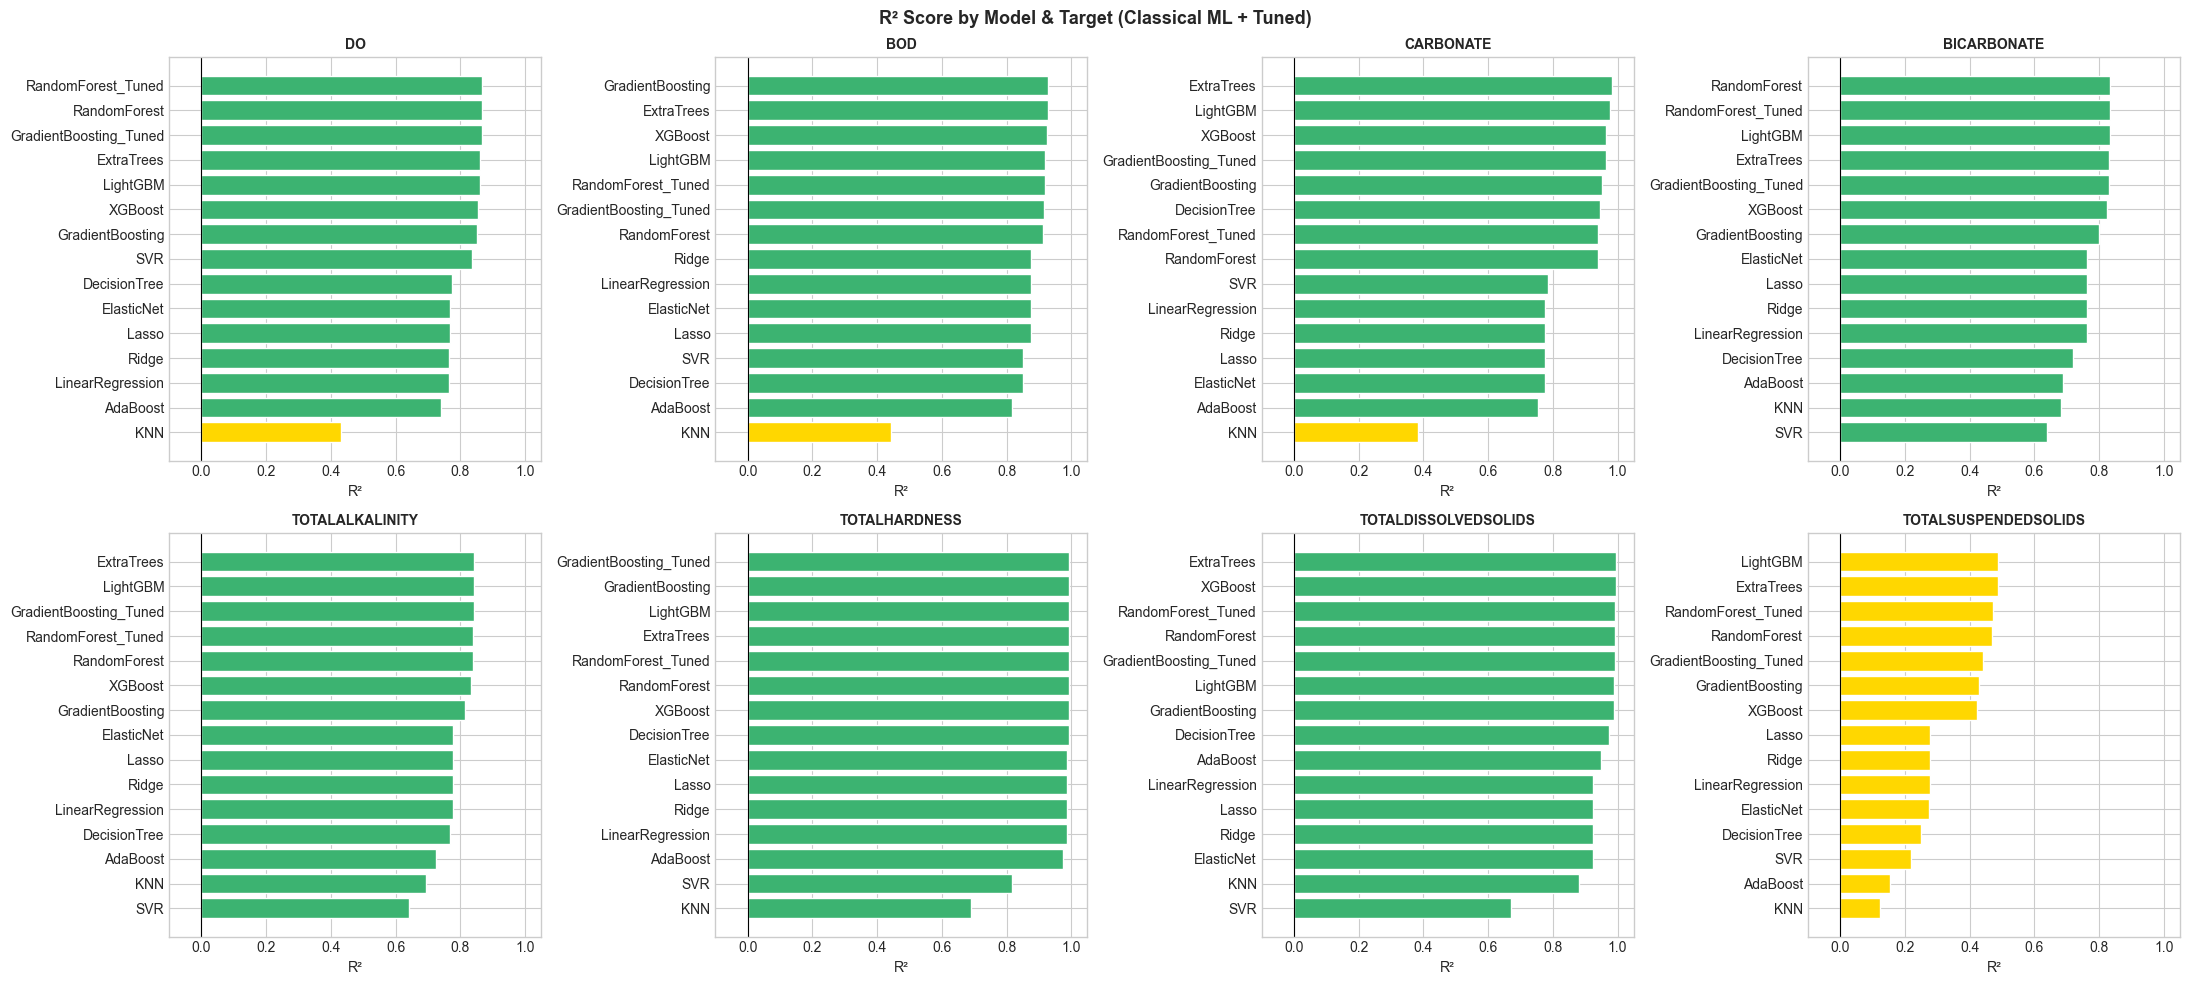

In [15]:
# ── R² Comparison bar chart per target ───────────────────────────────────────
n_targets = len(available_targets)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, target in enumerate(available_targets):
    if i >= len(axes): break
    sub = df_final[df_final['Target'] == target].sort_values('R2', ascending=True)
    colors = ['tomato' if r < 0 else ('gold' if r < 0.5 else 'mediumseagreen') for r in sub['R2']]
    axes[i].barh(sub['Model'], sub['R2'], color=colors, edgecolor='white')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{target}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('R²')
    axes[i].set_xlim(-0.1, 1.05)

# Hide unused
for j in range(len(available_targets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('R² Score by Model & Target (Classical ML + Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('05_r2_comparison_all_targets.png')
plt.show()

  💾 Saved → images/06_actual_vs_predicted_classical.png


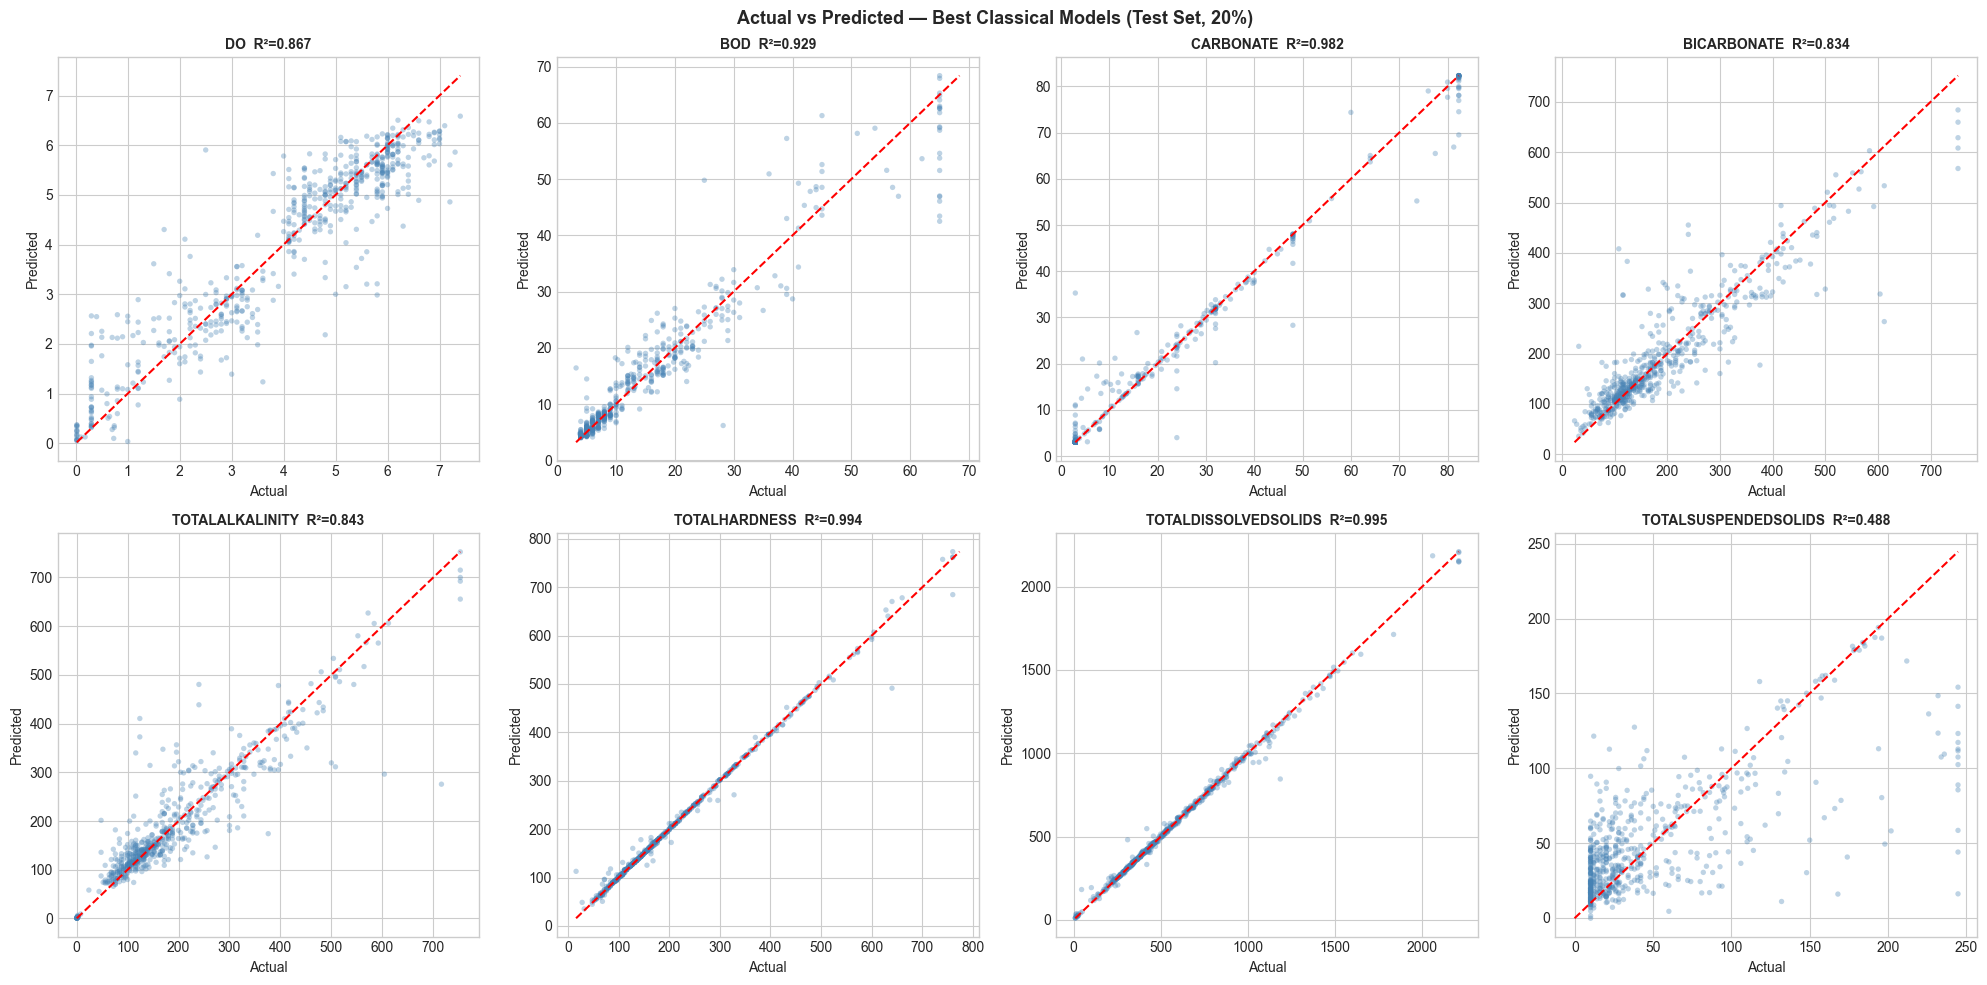

In [16]:
# ── Actual vs Predicted scatter for best models ───────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, target in enumerate(available_targets):
    if target not in best_preds or i >= len(axes): continue
    idx   = available_targets.index(target)
    act   = Y_test[:, idx]
    prd   = best_preds[target]
    r2    = r2_score(act, prd)
    axes[i].scatter(act, prd, alpha=0.35, s=15, c='steelblue', edgecolors='none')
    mn, mx = min(act.min(), prd.min()), max(act.max(), prd.max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    axes[i].set_title(f'{target}  R²={r2:.3f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Actual'); axes[i].set_ylabel('Predicted')

for j in range(len(available_targets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted — Best Classical Models (Test Set, 20%)', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('06_actual_vs_predicted_classical.png')
plt.show()

  💾 Saved → images/07_model_metric_heatmaps.png


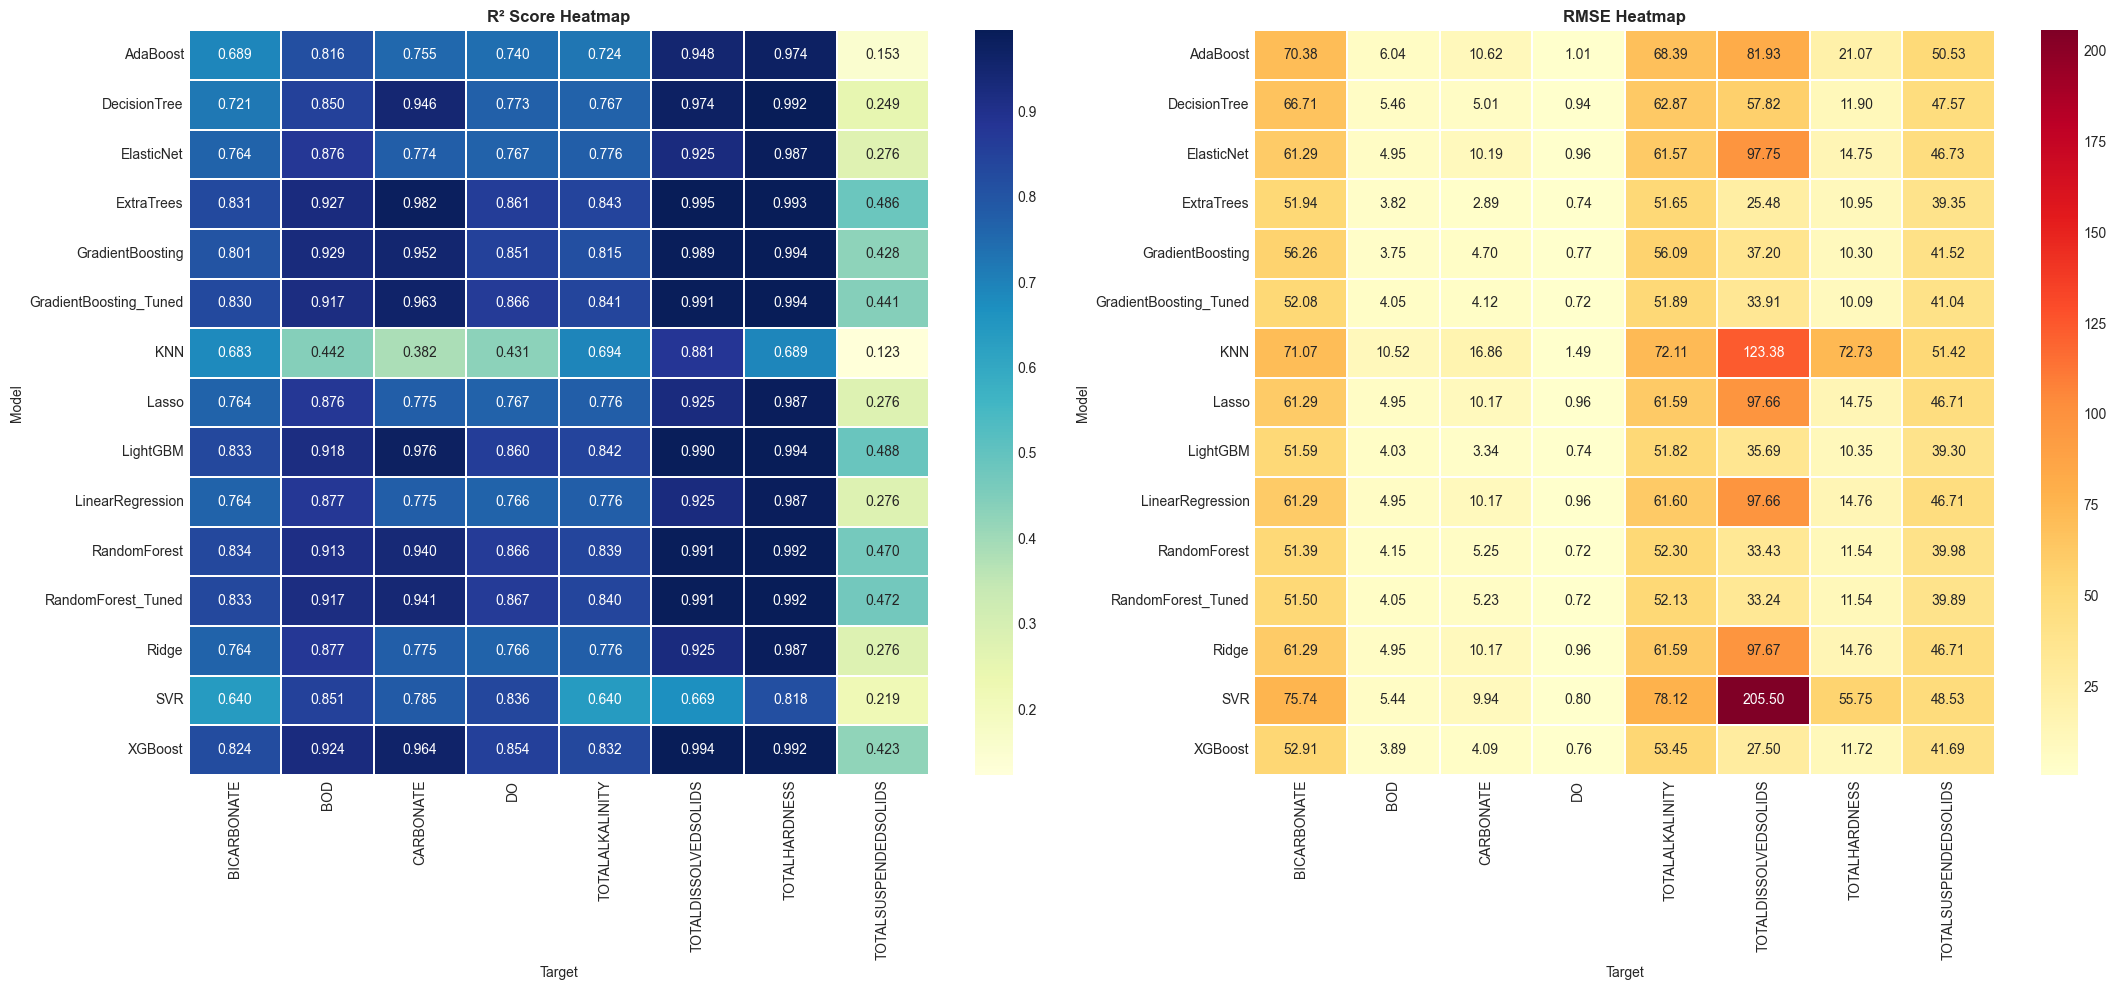

In [17]:
# ── RMSE heatmap ──────────────────────────────────────────────────────────────
pivot_rmse = df_final.pivot_table(index='Model', columns='Target', values='RMSE')
pivot_r2   = df_final.pivot_table(index='Model', columns='Target', values='R2')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
sns.heatmap(pivot_r2,   annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0], linewidths=0.3)
axes[0].set_title('R² Score Heatmap', fontweight='bold', fontsize=12)
sns.heatmap(pivot_rmse, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], linewidths=0.3)
axes[1].set_title('RMSE Heatmap', fontweight='bold', fontsize=12)
plt.tight_layout()
savefig('07_model_metric_heatmaps.png')
plt.show()

  💾 Saved → images/08_feature_importance_DO.png


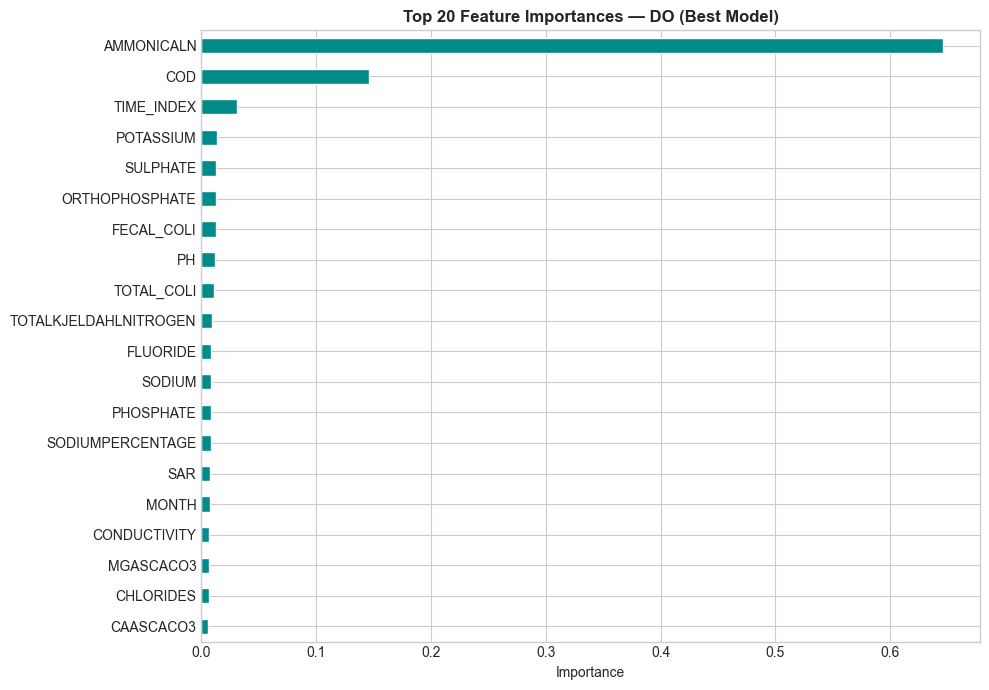

In [18]:
# ── Feature importance (RandomForest for DO as example) ──────────────────────
if 'DO' in available_targets and 'DO' in best_models:
    rf_do = best_models['DO']
    if hasattr(rf_do, 'feature_importances_'):
        fi = pd.Series(rf_do.feature_importances_, index=feature_cols).sort_values(ascending=False)[:20]
        fig, ax = plt.subplots(figsize=(10, 7))
        fi.plot(kind='barh', ax=ax, color='darkcyan', edgecolor='white')
        ax.invert_yaxis()
        ax.set_title('Top 20 Feature Importances — DO (Best Model)', fontweight='bold')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        savefig('08_feature_importance_DO.png')
        plt.show()

---
## 7. Deep Learning — FNN, 1D-CNN, LSTM

All three architectures trained on **scaled** features with the same 80-20 split.

In [19]:
if not HAS_TF:
    print('⚠️  TensorFlow not available. Skipping deep learning section.')
else:
    tf.random.set_seed(42)

    n_features = X_train_sc.shape[1]
    n_targets  = len(available_targets)

    CALLBACKS = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0)
    ]

    # ──────────────────────────────────────────────────────────────────────────
    # 7A. FNN — Feedforward Neural Network
    # ──────────────────────────────────────────────────────────────────────────
    def build_fnn(n_feat, n_out):
        inp = keras.Input(shape=(n_feat,), name='input')
        x = layers.Dense(256, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dense(32, activation='relu')(x)
        out = layers.Dense(n_out, activation='linear', name='output')(x)
        model = keras.Model(inp, out, name='FNN')
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss='mse', metrics=['mae'])
        return model

    fnn = build_fnn(n_features, n_targets)
    fnn.summary()

    hist_fnn = fnn.fit(
        X_train_sc, Y_train_sc,
        validation_split=0.15,
        epochs=200, batch_size=64,
        callbacks=CALLBACKS, verbose=1
    )
    print('✅ FNN training complete')

Model: "FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,200 (203.91 KB)

 Trainable params: 51,432 (200.91 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8117 - mae: 0.6479 - val_loss: 0.7061 - val_mae: 0.6178 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4662 - mae: 0.4791 - val_loss: 0.6399 - val_mae: 0.5807 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4029 - mae: 0.4386 - val_loss: 0.5655 - val_mae: 0.5420 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3708 - mae: 0.4120 - val_loss: 0.4991 - val_mae: 0.4992 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3492 - mae: 0.3970 - val_loss: 0.4440 - val_mae: 0.4629 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3297 - mae: 0.3829 - val_loss: 0.3987 - val_mae: 0.4286 - learning_rate: 0.0010
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3188 - mae: 0.3749 - val_loss: 0.3538 - val_mae: 0.3943 - learning_rate: 0.0010
Epoch 8/200
3

In [20]:
if HAS_TF:
    # ──────────────────────────────────────────────────────────────────────────
    # 7B. 1D-CNN — Convolutional Neural Network
    # ──────────────────────────────────────────────────────────────────────────
    def build_cnn(n_feat, n_out):
        inp  = keras.Input(shape=(n_feat, 1), name='input')
        x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        out = layers.Dense(n_out, activation='linear', name='output')(x)
        model = keras.Model(inp, out, name='CNN_1D')
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss='mse', metrics=['mae'])
        return model

    # Reshape for CNN: (samples, features, 1)
    X_train_cnn = X_train_sc.reshape(X_train_sc.shape[0], X_train_sc.shape[1], 1)
    X_test_cnn  = X_test_sc.reshape(X_test_sc.shape[0], X_test_sc.shape[1], 1)

    cnn = build_cnn(n_features, n_targets)
    cnn.summary()

    hist_cnn = cnn.fit(
        X_train_cnn, Y_train_sc,
        validation_split=0.15,
        epochs=200, batch_size=64,
        callbacks=CALLBACKS, verbose=1
    )
    print('✅ 1D-CNN training complete')

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 27, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 27, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,016 (199.28 KB)

 Trainable params: 50,632 (197.78 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6886 - mae: 0.5923 - val_loss: 0.9937 - val_mae: 0.7211 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5480 - mae: 0.5205 - val_loss: 1.0048 - val_mae: 0.6956 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4995 - mae: 0.4887 - val_loss: 1.0249 - val_mae: 0.6756 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4664 - mae: 0.4638 - val_loss: 1.0351 - val_mae: 0.6662 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4445 - mae: 0.4508 - val_loss: 1.0377 - val_mae: 0.6582 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4353 - mae: 0.4435 - val_loss: 1.0237 - val_mae: 0.6472 - learning_rate: 0.0010
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4189 - mae: 0.4324 - val_loss: 0.9988 - val_mae: 0.6405 - learning_rate: 0.0010
Epoch 8/200
3

In [21]:
if HAS_TF:
    # ──────────────────────────────────────────────────────────────────────────
    # 7C. LSTM — Long Short-Term Memory (Deep Learning)
    # ──────────────────────────────────────────────────────────────────────────
    def build_lstm(n_feat, n_out):
        inp = keras.Input(shape=(n_feat, 1), name='input')
        x = layers.LSTM(128, return_sequences=True, dropout=0.2,
                         recurrent_dropout=0.1)(inp)
        x = layers.LSTM(64, return_sequences=False, dropout=0.2)(x)
        x = layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
        out = layers.Dense(n_out, activation='linear', name='output')(x)
        model = keras.Model(inp, out, name='LSTM')
        model.compile(optimizer=keras.optimizers.Adam(5e-4),
                       loss='mse', metrics=['mae'])
        return model

    lstm = build_lstm(n_features, n_targets)
    lstm.summary()

    hist_lstm = lstm.fit(
        X_train_cnn, Y_train_sc,   # same reshape as CNN
        validation_split=0.15,
        epochs=200, batch_size=64,
        callbacks=CALLBACKS, verbose=1
    )
    print('✅ LSTM training complete')

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 27, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,472 (478.41 KB)

 Trainable params: 122,472 (478.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.9120 - mae: 0.6952 - val_loss: 0.7997 - val_mae: 0.6118 - learning_rate: 5.0000e-04
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7969 - mae: 0.6275 - val_loss: 0.7259 - val_mae: 0.5989 - learning_rate: 5.0000e-04
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7450 - mae: 0.6114 - val_loss: 0.6893 - val_mae: 0.5687 - learning_rate: 5.0000e-04
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7278 - mae: 0.6006 - val_loss: 0.6633 - val_mae: 0.5626 - learning_rate: 5.0000e-04
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7056 - mae: 0.5899 - val_loss: 0.6483 - val_mae: 0.5548 - learning_rate: 5.0000e-04
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6889 - mae: 0.5797 - val_loss: 0.6470 - val_mae: 0.5577 - learning_rate: 5.0000e-04
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6728 - mae: 0.5784 - val_loss: 0.6326 - val_mae: 0.5517 - lear

In [22]:
if HAS_TF:
    # ── Evaluate all DL models ────────────────────────────────────────────────
    def eval_dl_model(model, X_input, y_true_scaled, scaler_y, targets):
        pred_sc = model.predict(X_input, verbose=0)
        pred    = scaler_y.inverse_transform(pred_sc)
        results = {}
        for i, t in enumerate(targets):
            results[t] = evaluate(y_true_scaled[:, i] if y_true_scaled.ndim > 1 else y_true_scaled,
                                   pred[:, i])
        return results, pred

    Y_test_orig = scaler_Y.inverse_transform(Y_test_sc)

    res_fnn,  pred_fnn  = eval_dl_model(fnn,  X_test_sc,   Y_test_orig, scaler_Y, available_targets)
    res_cnn,  pred_cnn  = eval_dl_model(cnn,  X_test_cnn,  Y_test_orig, scaler_Y, available_targets)
    res_lstm, pred_lstm = eval_dl_model(lstm, X_test_cnn,  Y_test_orig, scaler_Y, available_targets)

    print('\n📊 Deep Learning Results:')
    print(f'  {"Target":<25} {"FNN R²":>8} {"CNN R²":>8} {"LSTM R²":>9}')
    print('  ' + '-'*55)
    for t in available_targets:
        print(f'  {t:<25} {res_fnn[t]["R2"]:>8.4f} {res_cnn[t]["R2"]:>8.4f} {res_lstm[t]["R2"]:>9.4f}')


📊 Deep Learning Results:
  Target                      FNN R²   CNN R²   LSTM R²
  -------------------------------------------------------
  DO                          0.8193   0.0352    0.4433
  BOD                         0.8892   0.0919    0.1654
  CARBONATE                   0.8418   0.0156    0.0452
  BICARBONATE                 0.8317   0.1069    0.3918
  TOTALALKALINITY             0.8399   0.1204    0.2712
  TOTALHARDNESS               0.9640   0.1078    0.3761
  TOTALDISSOLVEDSOLIDS        0.9561   0.1014    0.4595
  TOTALSUSPENDEDSOLIDS        0.4043   0.0091   -0.0167


  💾 Saved → images/09_dl_training_history.png


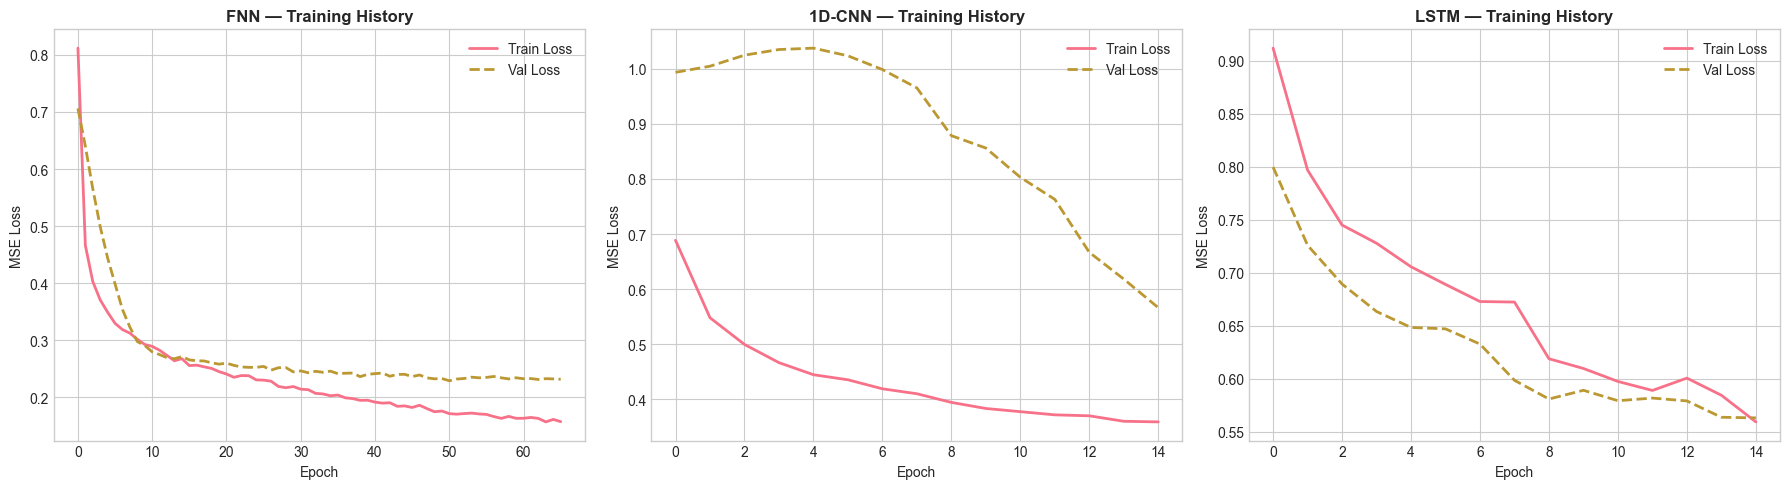

In [23]:
if HAS_TF:
    # ── Training history plots ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, hist, label in zip(axes,
                                [hist_fnn, hist_cnn, hist_lstm],
                                ['FNN', '1D-CNN', 'LSTM']):
        ax.plot(hist.history['loss'],     label='Train Loss', linewidth=2)
        ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
        ax.set_title(f'{label} — Training History', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend()
    plt.tight_layout()
    savefig('09_dl_training_history.png')
    plt.show()

  💾 Saved → images/10_actual_vs_predicted_FNN.png


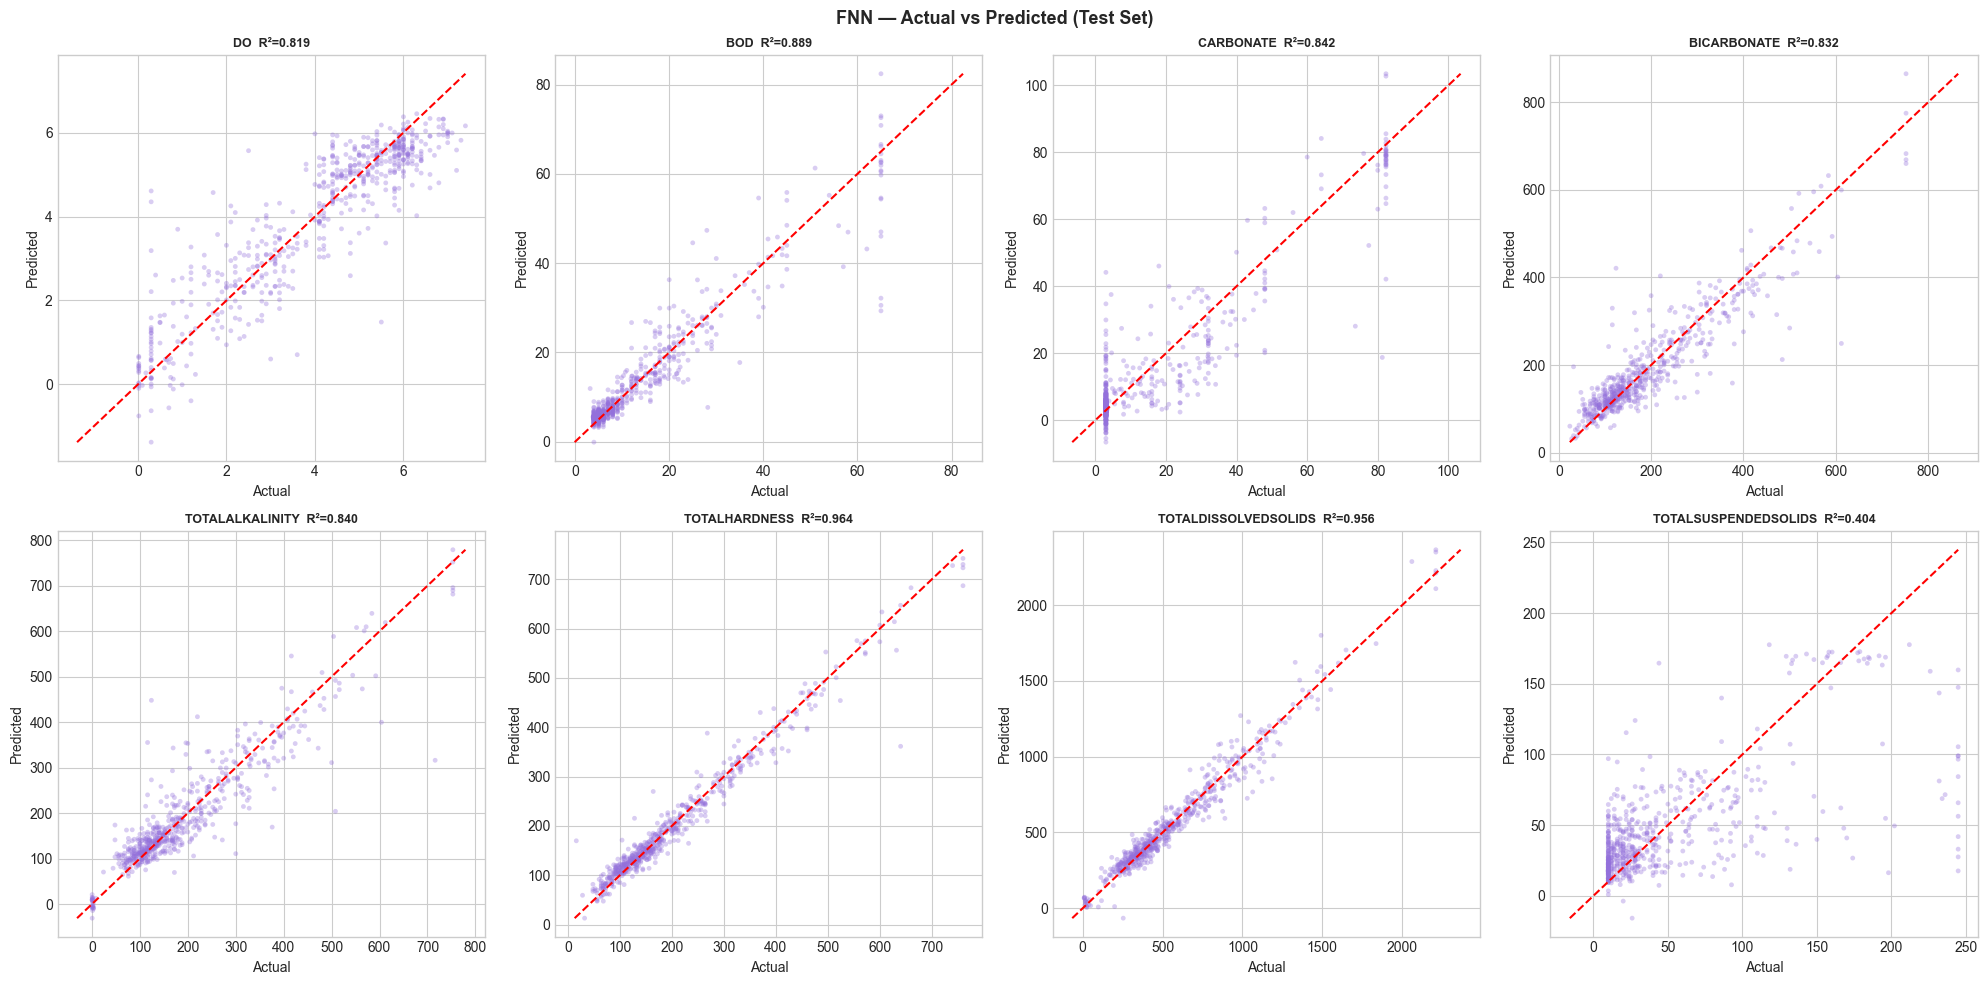

  💾 Saved → images/10_actual_vs_predicted_CNN.png


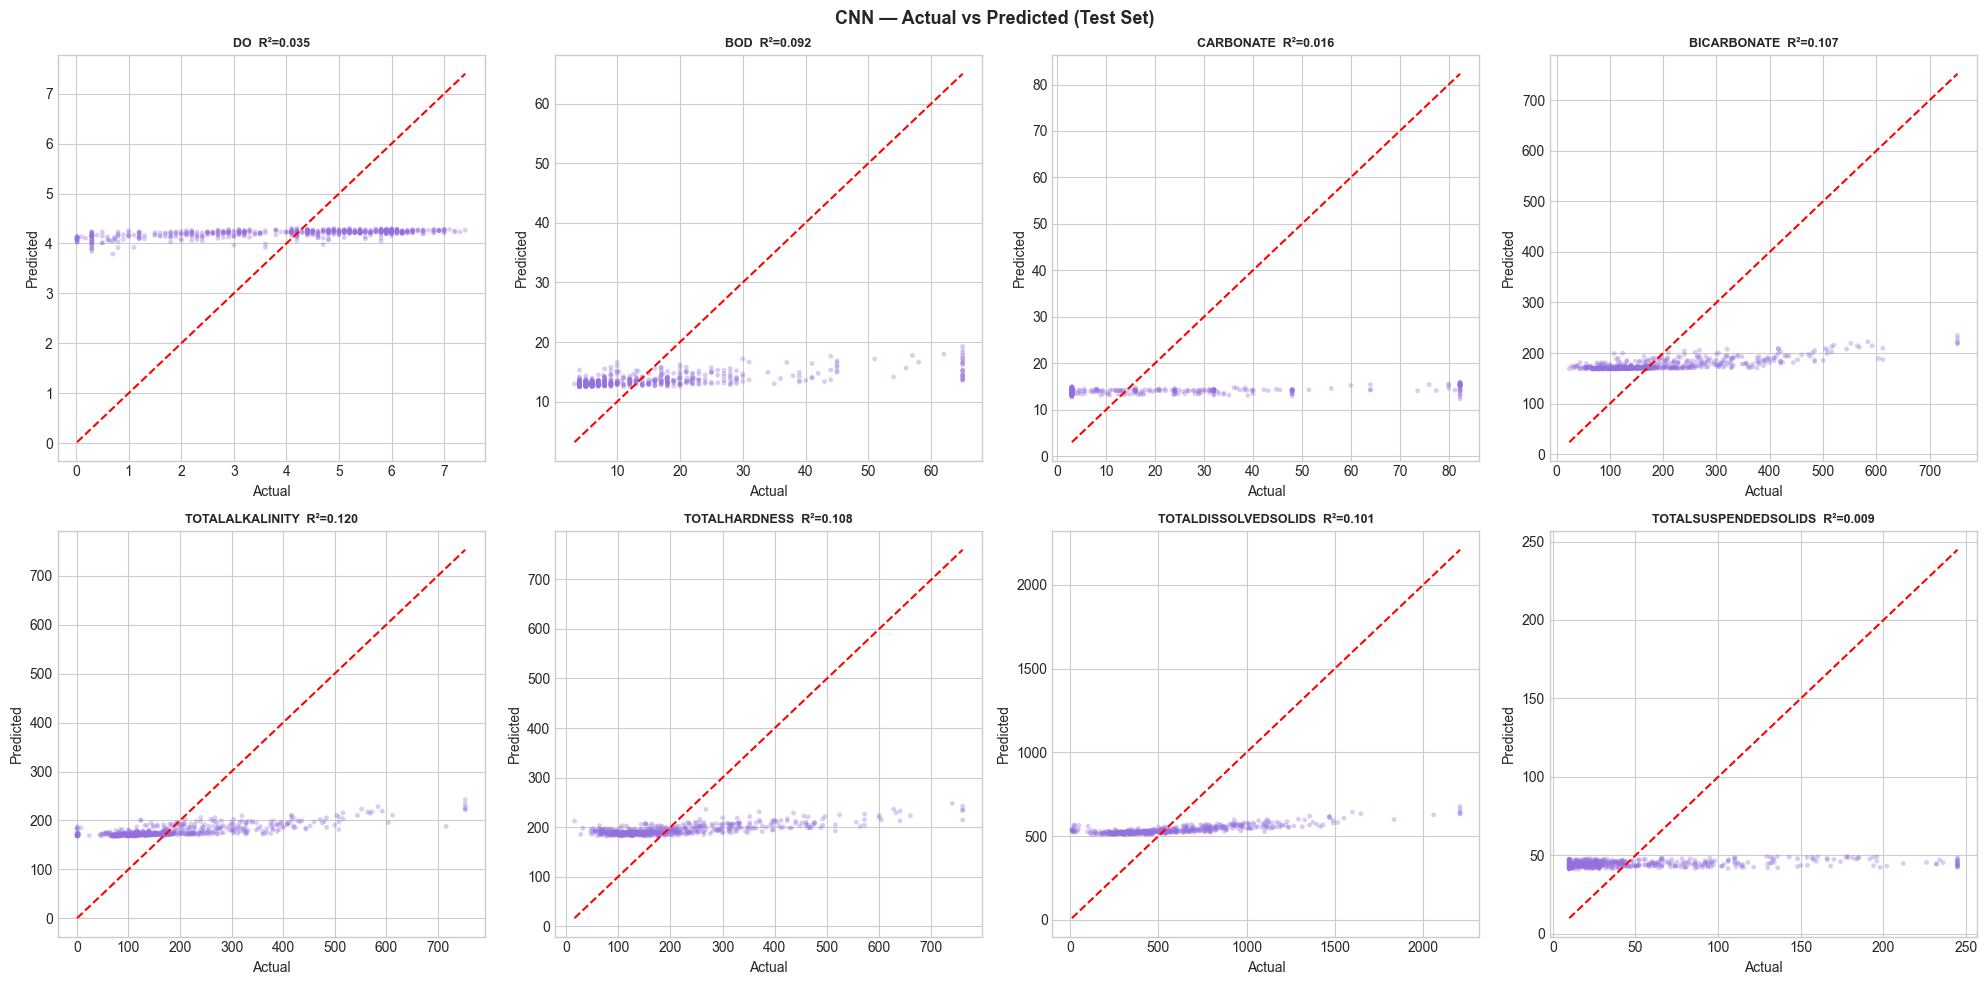

  💾 Saved → images/10_actual_vs_predicted_LSTM.png


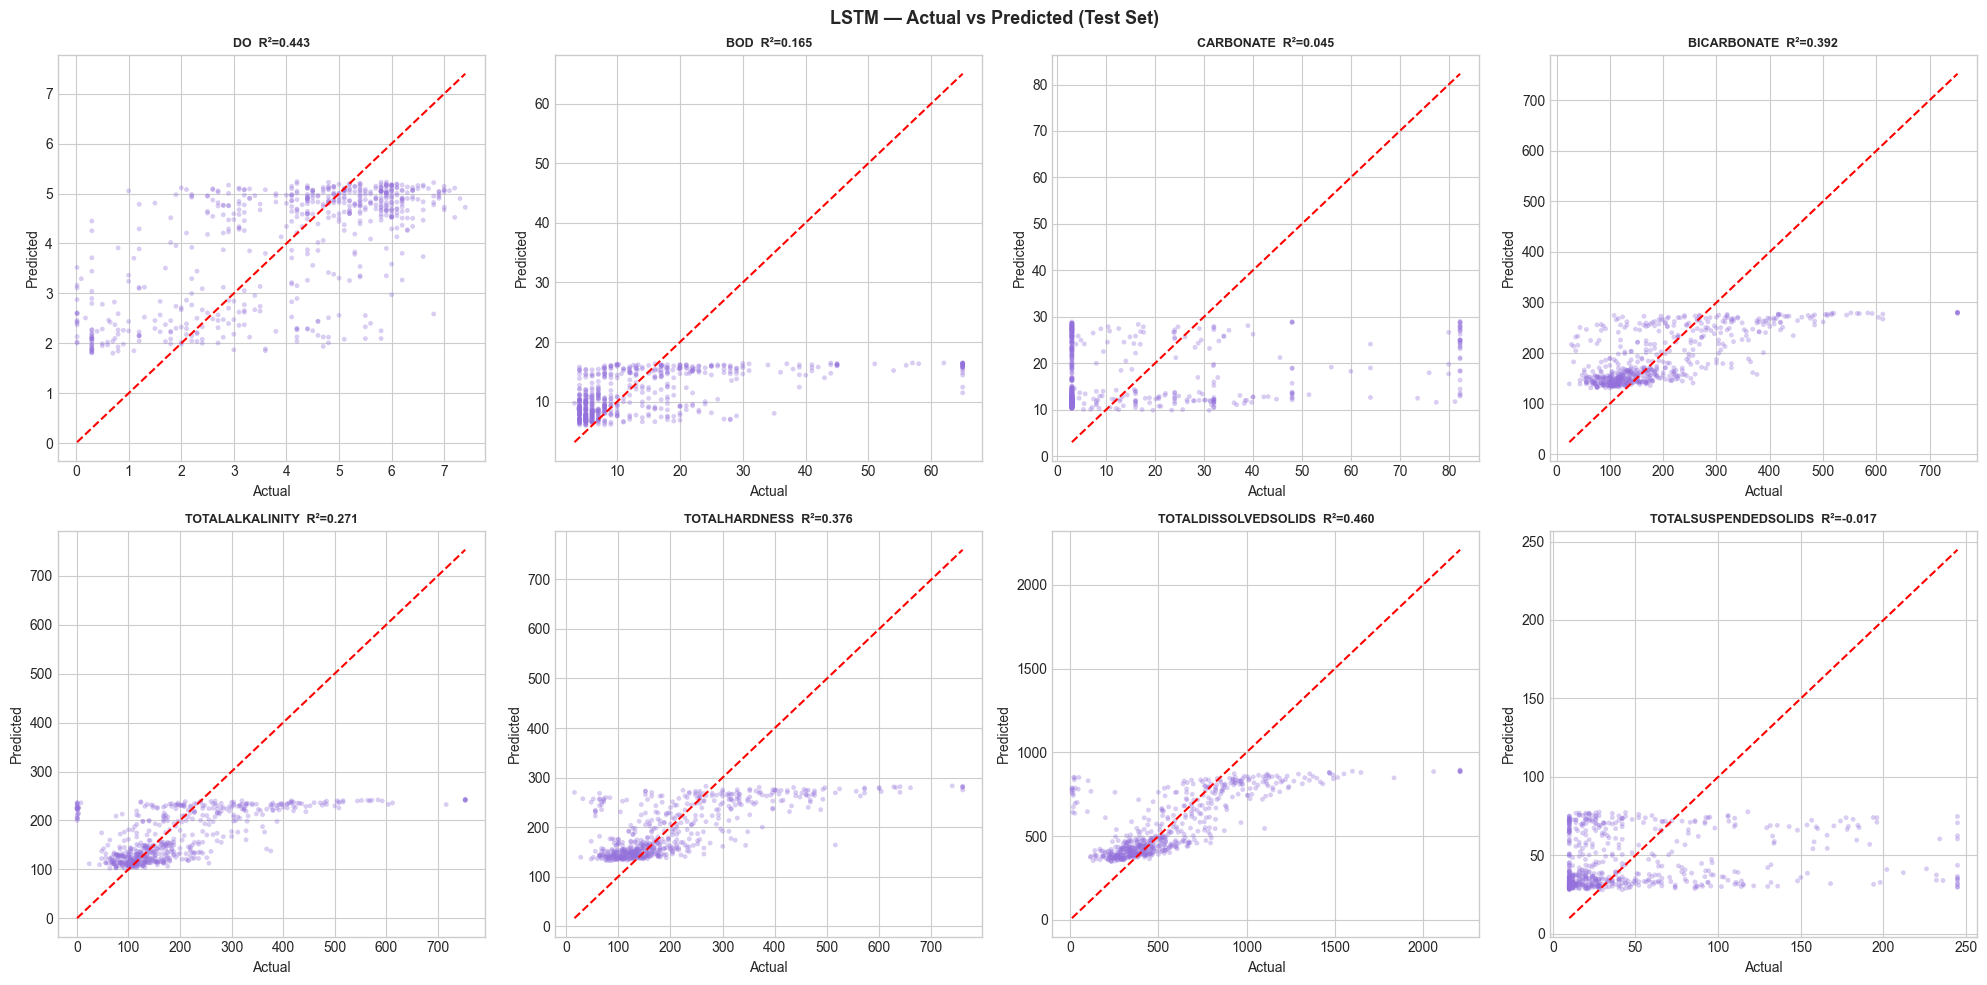

In [24]:
if HAS_TF:
    # ── DL Actual vs Predicted scatter ───────────────────────────────────────
    for dl_name, dl_pred in [('FNN', pred_fnn), ('CNN', pred_cnn), ('LSTM', pred_lstm)]:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        for i, target in enumerate(available_targets):
            if i >= len(axes): break
            idx  = available_targets.index(target)
            act  = Y_test[:, idx]
            prd  = dl_pred[:, idx]
            r2   = r2_score(act, prd)
            axes[i].scatter(act, prd, alpha=0.35, s=12, c='mediumpurple', edgecolors='none')
            mn, mx = min(act.min(), prd.min()), max(act.max(), prd.max())
            axes[i].plot([mn,mx],[mn,mx],'r--',linewidth=1.5)
            axes[i].set_title(f'{target}  R²={r2:.3f}', fontweight='bold', fontsize=9)
            axes[i].set_xlabel('Actual'); axes[i].set_ylabel('Predicted')
        for j in range(len(available_targets), len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f'{dl_name} — Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        savefig(f'10_actual_vs_predicted_{dl_name}.png')
        plt.show()

In [25]:
if HAS_TF:
    # ── Full model comparison: Classical Best + DL ────────────────────────────
    dl_records = []
    for t in available_targets:
        idx = available_targets.index(t)
        for dl_name, dl_res in [('FNN', res_fnn), ('CNN_1D', res_cnn), ('LSTM', res_lstm)]:
            dl_records.append({'Target': t, 'Model': dl_name, **dl_res[t]})
    df_dl = pd.DataFrame(dl_records)
    df_all = pd.concat([df_final, df_dl], ignore_index=True)

    # Summary table
    df_champion = df_all.loc[df_all.groupby('Target')['R2'].idxmax()].reset_index(drop=True)
    print('\n🏆 OVERALL CHAMPION MODEL per Target (Classical + DL):')
    print(df_champion[['Target','Model','R2','RMSE','MAE']].to_string(index=False))
else:
    df_all      = df_final.copy()
    df_champion = df_best_all.copy()


🏆 OVERALL CHAMPION MODEL per Target (Classical + DL):
              Target                  Model     R2    RMSE     MAE
         BICARBONATE           RandomForest 0.8342 51.3905 31.0957
                 BOD       GradientBoosting 0.9291  3.7504  2.0271
           CARBONATE             ExtraTrees 0.9819  2.8867  0.8526
                  DO     RandomForest_Tuned 0.8673  0.7213  0.5119
     TOTALALKALINITY             ExtraTrees 0.8427 51.6535 29.6113
TOTALDISSOLVEDSOLIDS             ExtraTrees 0.9949 25.4792 10.9169
       TOTALHARDNESS GradientBoosting_Tuned 0.9940 10.0882  3.1031
TOTALSUSPENDEDSOLIDS               LightGBM 0.4876 39.3022 24.4117


---
## 8. Complete Model Comparison Visualisations

  💾 Saved → images/11_classical_vs_dl_r2_comparison.png


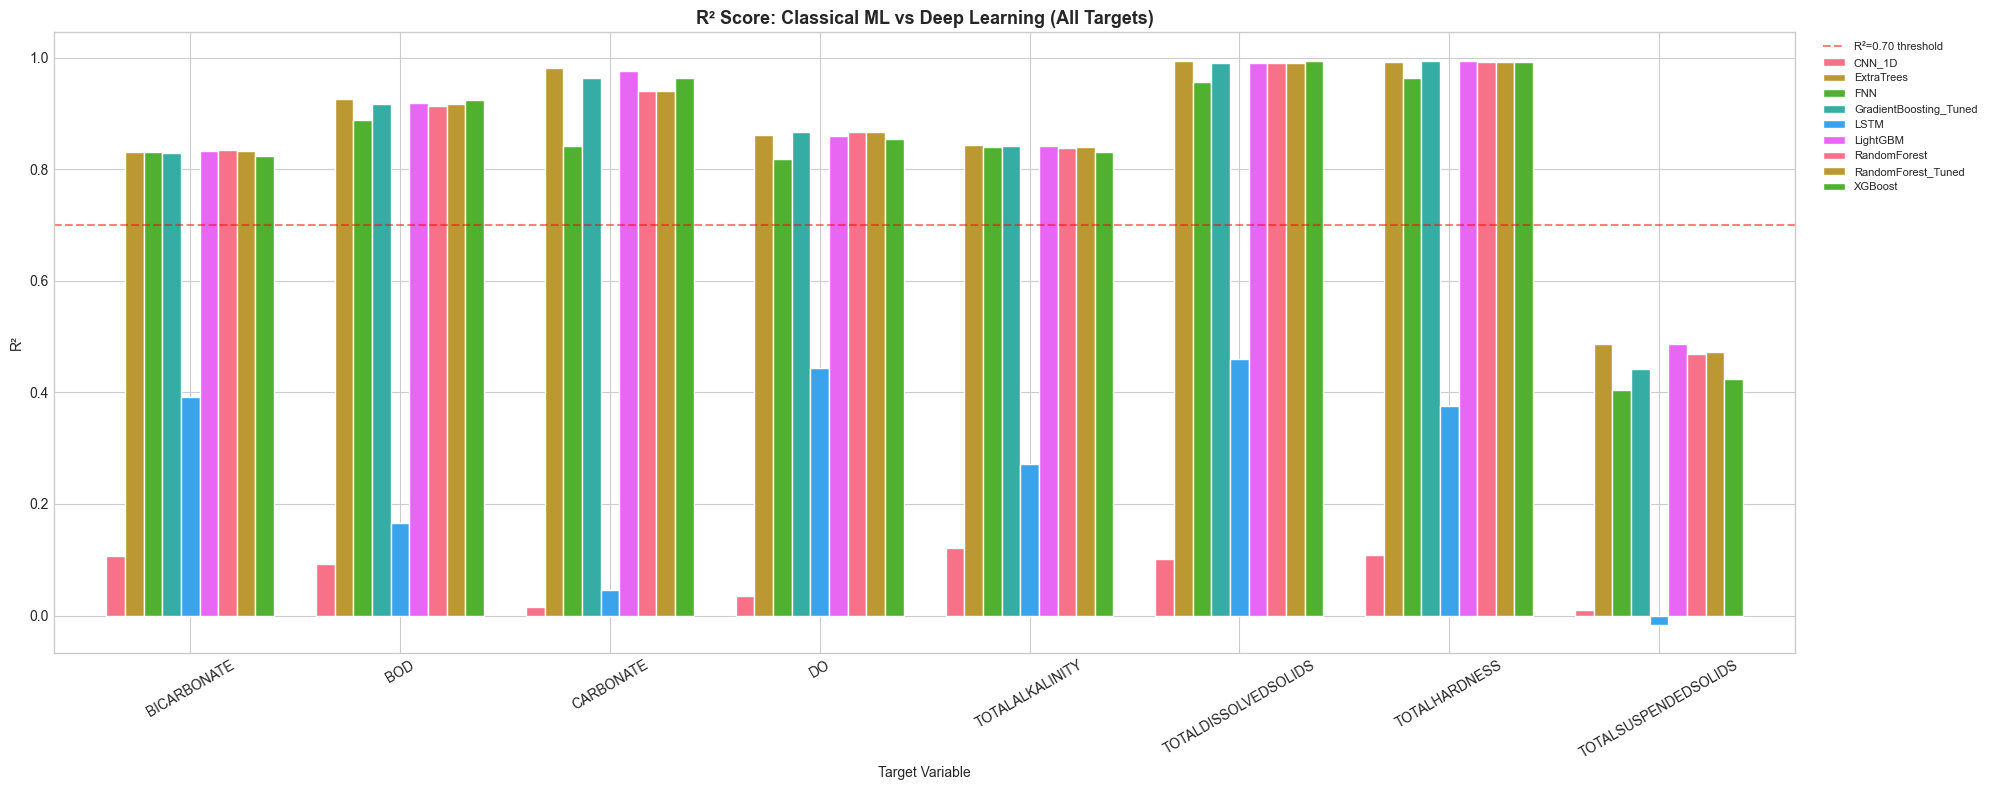

In [26]:
# ── Grouped R² bar chart: Classical vs DL per target ─────────────────────────
summary_models = ['RandomForest', 'ExtraTrees', 'LightGBM', 'XGBoost',
                   'GradientBoosting_Tuned', 'RandomForest_Tuned']
if HAS_TF:
    summary_models += ['FNN', 'CNN_1D', 'LSTM']

sub = df_all[df_all['Model'].isin(summary_models)]
pivot = sub.pivot_table(index='Target', columns='Model', values='R2')

fig, ax = plt.subplots(figsize=(20, 8))
pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_title('R² Score: Classical ML vs Deep Learning (All Targets)', fontsize=13, fontweight='bold')
ax.set_xlabel('Target Variable'); ax.set_ylabel('R²')
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='R²=0.70 threshold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
savefig('11_classical_vs_dl_r2_comparison.png')
plt.show()

---
## 9. Future Forecasting — Months April–August 2026

Using the best classical model per target to forecast the **next 5 months** (Apr–Aug 2026).

In [27]:
# ── Build future feature rows for Apr–Aug 2026 ────────────────────────────────
# Strategy: extrapolate using the median of each non-temporal feature,
# and set temporal features (MONTH, YEAR_NUM, sin/cos, TIME_INDEX) exactly.

FUTURE_MONTHS = [
    {'label': 'Apr-2026', 'month': 4,  'year': 2026},
    {'label': 'May-2026', 'month': 5,  'year': 2026},
    {'label': 'Jun-2026', 'month': 6,  'year': 2026},
    {'label': 'Jul-2026', 'month': 7,  'year': 2026},
    {'label': 'Aug-2026', 'month': 8,  'year': 2026},
]

TEMPORAL_COLS = ['MONTH', 'YEAR_NUM', 'MONTH_SIN', 'MONTH_COS', 'TIME_INDEX']
non_temporal  = [c for c in feature_cols if c not in TEMPORAL_COLS]

# Use median of training set for non-temporal features
train_df = pd.DataFrame(X_train, columns=feature_cols)
feature_medians = train_df[non_temporal].median()

future_rows = []
for fm in FUTURE_MONTHS:
    row = feature_medians.copy()
    row['MONTH']       = fm['month']
    row['YEAR_NUM']    = fm['year']
    row['MONTH_SIN']   = np.sin(2 * np.pi * fm['month'] / 12)
    row['MONTH_COS']   = np.cos(2 * np.pi * fm['month'] / 12)
    row['TIME_INDEX']  = (fm['year'] - 2023) * 12 + fm['month']
    future_rows.append(row)

X_future = pd.DataFrame(future_rows, columns=feature_cols).values
X_future_sc = scaler_X.transform(X_future)

print('✅ Future feature matrix built for:', [fm['label'] for fm in FUTURE_MONTHS])
print(f'   Shape: {X_future.shape}')

✅ Future feature matrix built for: ['Apr-2026', 'May-2026', 'Jun-2026', 'Jul-2026', 'Aug-2026']
   Shape: (5, 27)


In [28]:
# ── Forecast with best classical models ───────────────────────────────────────
forecast_classical = {}
for target in available_targets:
    if target not in best_models: continue
    mdl   = best_models[target]
    Xfut  = X_future_sc if isinstance(mdl, SVR) else X_future
    preds = mdl.predict(Xfut)
    forecast_classical[target] = preds

# ── Forecast with DL models ───────────────────────────────────────────────────
if HAS_TF:
    X_future_cnn = X_future_sc.reshape(X_future_sc.shape[0], X_future_sc.shape[1], 1)

    def dl_forecast(model, X_input):
        pred_sc = model.predict(X_input, verbose=0)
        return scaler_Y.inverse_transform(pred_sc)

    forecast_fnn  = dl_forecast(fnn,  X_future_sc)
    forecast_cnn  = dl_forecast(cnn,  X_future_cnn)
    forecast_lstm = dl_forecast(lstm, X_future_cnn)

    forecast_dl_mean = (forecast_fnn + forecast_cnn + forecast_lstm) / 3  # ensemble
    print('✅ DL ensemble forecast (FNN+CNN+LSTM mean) computed')

print('✅ Classical + DL forecasts ready')

✅ DL ensemble forecast (FNN+CNN+LSTM mean) computed
✅ Classical + DL forecasts ready


In [29]:
# ── Build forecast dataframe ──────────────────────────────────────────────────
forecast_labels = [fm['label'] for fm in FUTURE_MONTHS]
df_forecast = pd.DataFrame({'Month': forecast_labels})

for target in available_targets:
    if target in forecast_classical:
        df_forecast[f'{target}_Classical'] = forecast_classical[target]

if HAS_TF:
    for i, target in enumerate(available_targets):
        df_forecast[f'{target}_DL_Ensemble'] = forecast_dl_mean[:, i]

print('\n📅 Forecast Table (Apr–Aug 2026):')
print(df_forecast.to_string(index=False))


📅 Forecast Table (Apr–Aug 2026):
   Month  DO_Classical  BOD_Classical  CARBONATE_Classical  BICARBONATE_Classical  TOTALALKALINITY_Classical  TOTALHARDNESS_Classical  TOTALDISSOLVEDSOLIDS_Classical  TOTALSUSPENDEDSOLIDS_Classical  DO_DL_Ensemble  BOD_DL_Ensemble  CARBONATE_DL_Ensemble  BICARBONATE_DL_Ensemble  TOTALALKALINITY_DL_Ensemble  TOTALHARDNESS_DL_Ensemble  TOTALDISSOLVEDSOLIDS_DL_Ensemble  TOTALSUSPENDEDSOLIDS_DL_Ensemble
Apr-2026        4.8130       7.450878            16.141238                 161.24                     164.48               164.194951                          503.19                        9.687525        4.617690         9.823156              10.399805               158.528381                   150.340790                 169.066849                        455.738251                         31.871315
May-2026        4.7825       7.505312            16.141238                 161.68                     166.96               164.194951                          5

  💾 Saved → images/12_forecast_apr_aug_2026.png


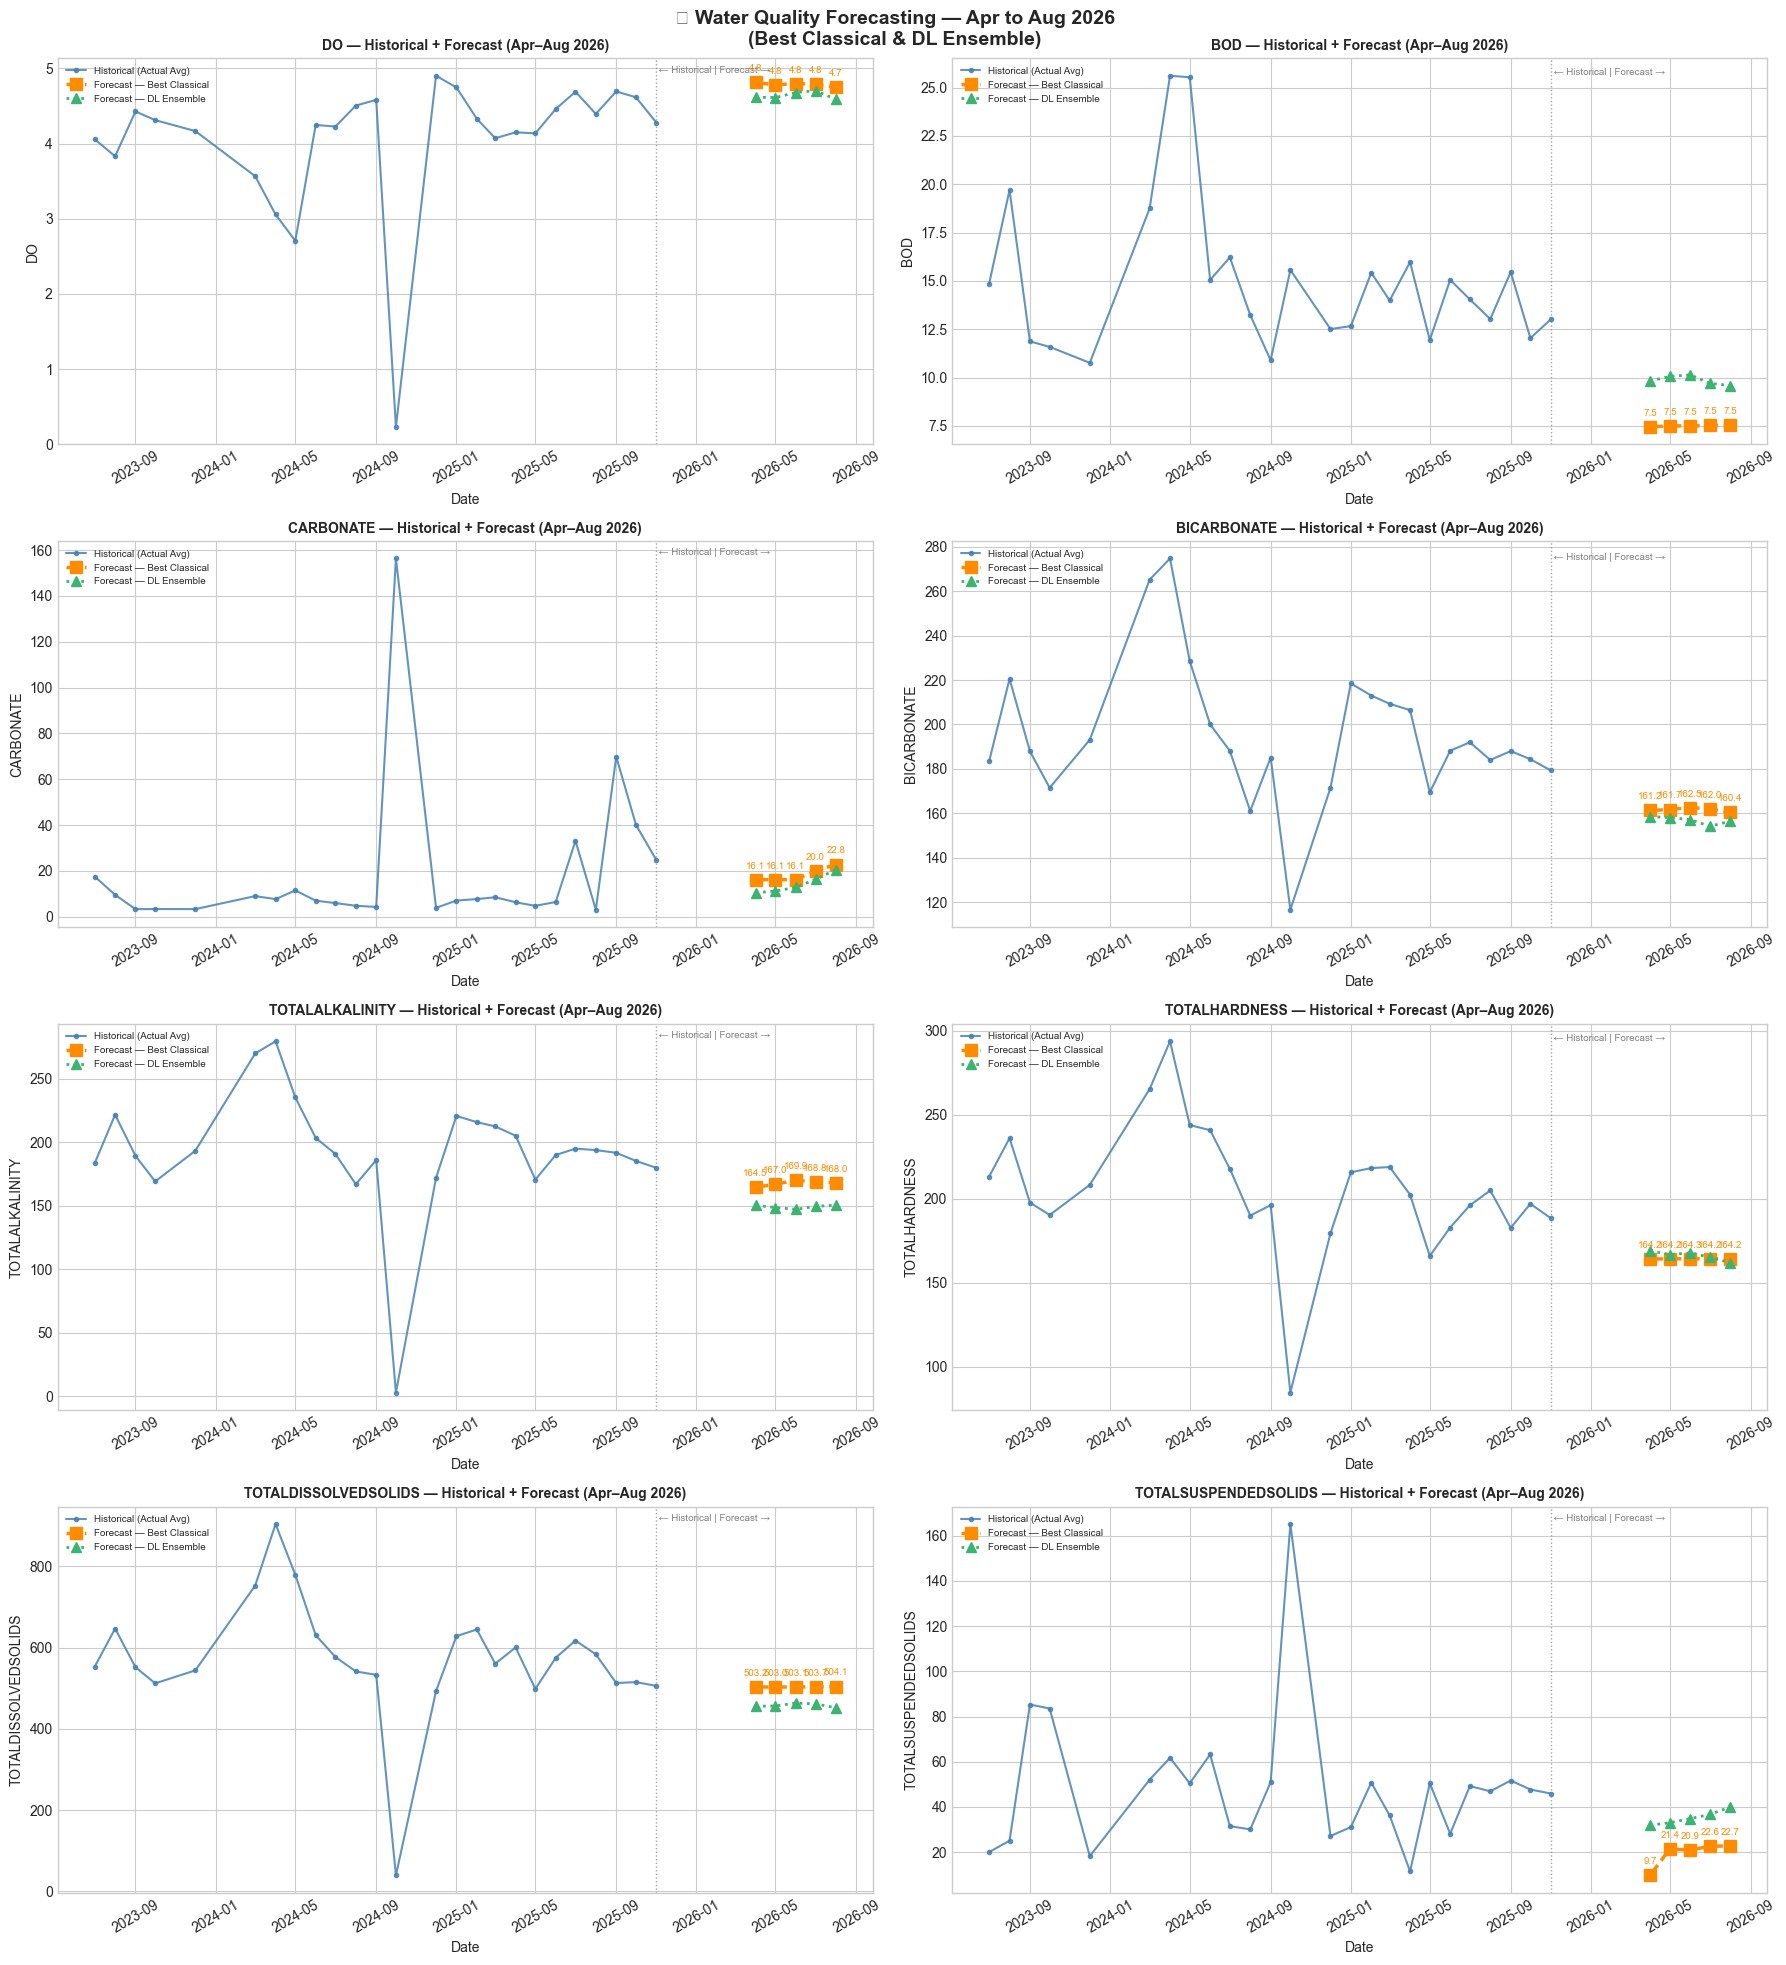

In [30]:
# ── Historical monthly means + forecasted extension ───────────────────────────
# Historical
df_hist = df_ts.groupby('DATE')[available_targets].mean().reset_index()
df_hist = df_hist.sort_values('DATE')

# Future dates
from dateutil.relativedelta import relativedelta
import datetime
future_dates = [datetime.date(fm['year'], fm['month'], 1) for fm in FUTURE_MONTHS]

# ── Plot forecast for each target ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
colors_hist = sns.color_palette('Blues_d', 1)
colors_cl   = sns.color_palette('Oranges_d', 1)
colors_dl   = sns.color_palette('Greens_d',  1) if HAS_TF else []

for i, target in enumerate(available_targets):
    if i >= len(axes): break
    ax = axes[i]

    # Historical trend
    ax.plot(df_hist['DATE'], df_hist[target],
            marker='o', markersize=3, linewidth=1.5,
            color='steelblue', label='Historical (Actual Avg)', alpha=0.85)

    # Classical forecast
    if target in forecast_classical:
        ax.plot(future_dates, forecast_classical[target],
                marker='s', markersize=8, linewidth=2.5,
                color='darkorange', linestyle='--',
                label='Forecast — Best Classical')
        for j, (d, v) in enumerate(zip(future_dates, forecast_classical[target])):
            ax.annotate(f'{v:.1f}', (d, v), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=7, color='darkorange')

    # DL ensemble forecast
    if HAS_TF:
        ax.plot(future_dates, forecast_dl_mean[:, i],
                marker='^', markersize=7, linewidth=2,
                color='mediumseagreen', linestyle=':',
                label='Forecast — DL Ensemble')

    # Vertical separator
    last_hist = df_hist['DATE'].max()
    ax.axvline(last_hist, color='gray', linestyle=':', alpha=0.7, linewidth=1)
    ax.text(last_hist, ax.get_ylim()[1] * 0.98, ' ← Historical | Forecast →',
            fontsize=7, va='top', color='gray')

    ax.set_title(f'{target} — Historical + Forecast (Apr–Aug 2026)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Date'); ax.set_ylabel(target)
    ax.legend(fontsize=7, loc='best')
    ax.tick_params(axis='x', rotation=30)

for j in range(len(available_targets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📅 Water Quality Forecasting — Apr to Aug 2026\n(Best Classical & DL Ensemble)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('12_forecast_apr_aug_2026.png')
plt.show()

  💾 Saved → images/13_forecast_bar_chart_2026.png


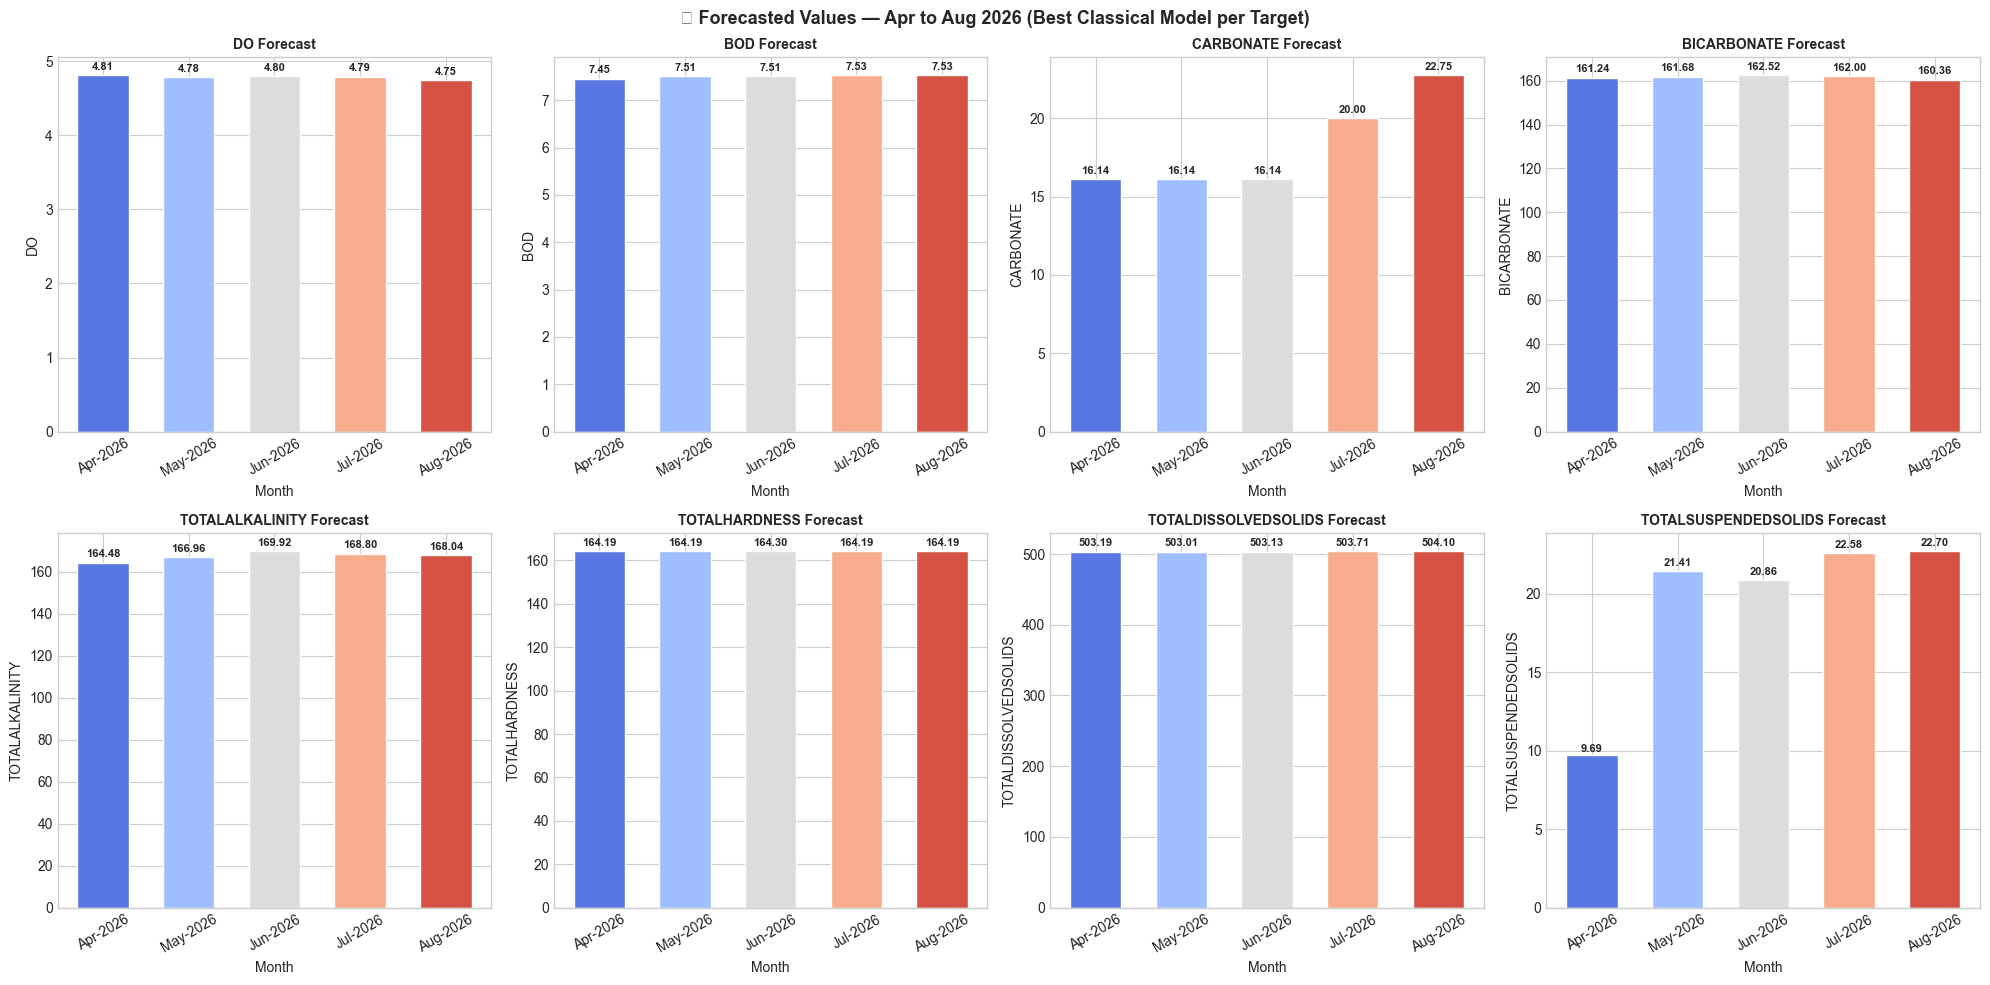

In [31]:
# ── Forecast trend summary bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
bar_colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(FUTURE_MONTHS)))

for i, target in enumerate(available_targets):
    if target not in forecast_classical or i >= len(axes): continue
    ax = axes[i]
    vals = forecast_classical[target]
    ax.bar(forecast_labels, vals, color=bar_colors, edgecolor='white', width=0.6)
    for j, v in enumerate(vals):
        ax.text(j, v * 1.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(f'{target} Forecast', fontweight='bold', fontsize=10)
    ax.set_xlabel('Month'); ax.set_ylabel(target)
    ax.tick_params(axis='x', rotation=30)

for j in range(len(available_targets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Forecasted Values — Apr to Aug 2026 (Best Classical Model per Target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('13_forecast_bar_chart_2026.png')
plt.show()

In [32]:
# ── Trend direction analysis ──────────────────────────────────────────────────
print('\n📈 Forecast Trend Analysis (Apr–Aug 2026):')
print(f'  {"Target":<30} {"Apr":>8} {"May":>8} {"Jun":>8} {"Jul":>8} {"Aug":>8}  Trend')
print('  ' + '-'*80)
for target in available_targets:
    if target not in forecast_classical: continue
    vals = forecast_classical[target]
    slope = np.polyfit(range(len(vals)), vals, 1)[0]
    trend = '📈 Rising' if slope > 0.01 * np.mean(vals) else ('📉 Falling' if slope < -0.01 * np.mean(vals) else '➡️  Stable')
    print(f'  {target:<30} {vals[0]:>8.2f} {vals[1]:>8.2f} {vals[2]:>8.2f} {vals[3]:>8.2f} {vals[4]:>8.2f}  {trend}')


📈 Forecast Trend Analysis (Apr–Aug 2026):
  Target                              Apr      May      Jun      Jul      Aug  Trend
  --------------------------------------------------------------------------------
  DO                                 4.81     4.78     4.80     4.79     4.75  ➡️  Stable
  BOD                                7.45     7.51     7.51     7.53     7.53  ➡️  Stable
  CARBONATE                         16.14    16.14    16.14    20.00    22.75  📈 Rising
  BICARBONATE                      161.24   161.68   162.52   162.00   160.36  ➡️  Stable
  TOTALALKALINITY                  164.48   166.96   169.92   168.80   168.04  ➡️  Stable
  TOTALHARDNESS                    164.19   164.19   164.30   164.19   164.19  ➡️  Stable
  TOTALDISSOLVEDSOLIDS             503.19   503.01   503.13   503.71   504.10  ➡️  Stable
  TOTALSUSPENDEDSOLIDS               9.69    21.41    20.86    22.58    22.70  📈 Rising


---
## 10. Export Results & Final Leaderboard

In [33]:
# ── Export predictions on test set ────────────────────────────────────────────
test_df = pd.DataFrame(Y_test, columns=[f'{t}_Actual' for t in available_targets])
for target in available_targets:
    if target in best_preds:
        test_df[f'{target}_PRED_Classical'] = best_preds[target]

if HAS_TF:
    for i, target in enumerate(available_targets):
        test_df[f'{target}_PRED_FNN']  = pred_fnn[:, i]
        test_df[f'{target}_PRED_CNN']  = pred_cnn[:, i]
        test_df[f'{target}_PRED_LSTM'] = pred_lstm[:, i]

test_df.to_csv('predictions_output.csv', index=False)
print(f'✅ predictions_output.csv saved ({test_df.shape})')
test_df.head()

✅ predictions_output.csv saved ((585, 40))


,DO_Actual,BOD_Actual,CARBONATE_Actual,BICARBONATE_Actual,TOTALALKALINITY_Actual,TOTALHARDNESS_Actual,TOTALDISSOLVEDSOLIDS_Actual,TOTALSUSPENDEDSOLIDS_Actual,DO_PRED_Classical,BOD_PRED_Classical,...,TOTALALKALINITY_PRED_LSTM,TOTALHARDNESS_PRED_FNN,TOTALHARDNESS_PRED_CNN,TOTALHARDNESS_PRED_LSTM,TOTALDISSOLVEDSOLIDS_PRED_FNN,TOTALDISSOLVEDSOLIDS_PRED_CNN,TOTALDISSOLVEDSOLIDS_PRED_LSTM,TOTALSUSPENDEDSOLIDS_PRED_FNN,TOTALSUSPENDEDSOLIDS_PRED_CNN,TOTALSUSPENDEDSOLIDS_PRED_LSTM
0,1.8,18.0,3.0,388.0,388.0,376.0,928.0,86.000000,2.518000,16.564174,...,230.820343,387.966125,202.255157,264.761658,907.432007,558.620667,805.833008,26.790516,45.379932,71.443298
1,2.9,16.0,3.0,272.0,272.0,360.0,952.0,15.000000,2.963417,13.884196,...,223.236420,377.497681,197.213806,245.861176,874.228516,546.366516,750.640625,26.381329,45.707451,65.780670
2,5.8,5.0,3.0,132.0,132.0,156.0,312.0,92.000000,5.767250,6.743666,...,143.749710,151.205566,187.916672,162.712158,358.707153,523.353516,462.887299,61.841759,43.737030,36.433121
3,6.0,6.0,3.0,128.0,128.0,156.0,380.0,14.000000,5.451500,9.149761,...,143.335358,152.572205,190.834152,164.130447,424.072021,527.456360,463.929657,21.106083,44.674088,36.778904
4,0.9,21.0,3.0,416.0,416.0,400.0,1006.0,244.751799,1.097300,23.471984,...,237.443192,394.639954,214.079010,275.463745,919.026489,578.506165,854.163635,147.450409,46.891678,74.819458


In [34]:
# ── Export forecast CSV ───────────────────────────────────────────────────────
df_forecast.to_csv('forecast_apr_aug_2026.csv', index=False)
print('✅ forecast_apr_aug_2026.csv saved')
df_forecast

✅ forecast_apr_aug_2026.csv saved


,Month,DO_Classical,BOD_Classical,CARBONATE_Classical,BICARBONATE_Classical,TOTALALKALINITY_Classical,TOTALHARDNESS_Classical,TOTALDISSOLVEDSOLIDS_Classical,TOTALSUSPENDEDSOLIDS_Classical,DO_DL_Ensemble,BOD_DL_Ensemble,CARBONATE_DL_Ensemble,BICARBONATE_DL_Ensemble,TOTALALKALINITY_DL_Ensemble,TOTALHARDNESS_DL_Ensemble,TOTALDISSOLVEDSOLIDS_DL_Ensemble,TOTALSUSPENDEDSOLIDS_DL_Ensemble
0,Apr-2026,4.8130,7.450878,16.141238,161.24,164.48,164.194951,503.19,9.687525,4.617690,9.823156,10.399805,158.528381,150.340790,169.066849,455.738251,31.871315
1,May-2026,4.7825,7.505312,16.141238,161.68,166.96,164.194951,503.01,21.406869,4.612997,10.063560,11.166302,158.003860,148.521530,166.749710,456.394043,32.984615
2,Jun-2026,4.7980,7.505312,16.141238,162.52,169.92,164.296044,503.13,20.857508,4.679419,10.145347,12.715175,157.145096,147.174622,167.794800,463.542236,34.799400
3,Jul-2026,4.7910,7.531699,20.001524,162.00,168.80,164.194951,503.71,22.576056,4.704210,9.702400,16.282141,154.110703,149.442520,165.185303,461.337982,36.631542
4,Aug-2026,4.7470,7.531699,22.750306,160.36,168.04,164.194951,504.10,22.700739,4.588732,9.592628,20.453423,156.446960,150.469894,161.934525,451.963837,39.943607


In [35]:
# ── Final Leaderboard ─────────────────────────────────────────────────────────
print('\n' + '='*80)
print('  FINAL LEADERBOARD — Best Model per Target (Classical + Deep Learning)')
print('='*80)
for _, row in df_champion.iterrows():
    print(f'  {row["Target"]:<30} → {row["Model"]:<28}  R²={row["R2"]:.4f}  RMSE={row["RMSE"]:.4f}')
print('='*80)

print('\n📁 All images saved to images/ folder:')
for f in sorted(IMAGES_DIR.glob('*.png')):
    print(f'   {f}')


  FINAL LEADERBOARD — Best Model per Target (Classical + Deep Learning)
  BICARBONATE                    → RandomForest                  R²=0.8342  RMSE=51.3905
  BOD                            → GradientBoosting              R²=0.9291  RMSE=3.7504
  CARBONATE                      → ExtraTrees                    R²=0.9819  RMSE=2.8867
  DO                             → RandomForest_Tuned            R²=0.8673  RMSE=0.7213
  TOTALALKALINITY                → ExtraTrees                    R²=0.8427  RMSE=51.6535
  TOTALDISSOLVEDSOLIDS           → ExtraTrees                    R²=0.9949  RMSE=25.4792
  TOTALHARDNESS                  → GradientBoosting_Tuned        R²=0.9940  RMSE=10.0882
  TOTALSUSPENDEDSOLIDS           → LightGBM                      R²=0.4876  RMSE=39.3022

📁 All images saved to images/ folder:
   images/01_target_distributions_raw.png
   images/02_correlation_heatmap.png
   images/03_monthly_trends.png
   images/04_target_distributions_cleaned.png
   images/05_r2_compar